# COMP8420 – Use Case 6: E-commerce Intelligent System
## Final Combined Project Notebook

**Team Members:** Snigdha, Aswin, Naseer, Ashon

This notebook encompasses the full implementation of Basic and Advanced NLP techniques to build an E-commerce Intelligent System. It emphasizes advanced LLM processing, Retrieval Augmented Generation (RAG), Prompt Engineering, and Agentic Design.


# COMP8420 — Assignment 3: E-commerce Intelligent System
## Basic NLP Techniques Module
### Contributor: Snigdha

**Use Case 6:** E-commerce Intelligent System — Amazon Product Reviews

This notebook implements and evaluates three basic NLP techniques using the Datafiniti Consumer Reviews of Amazon Products dataset (Kaggle, 34,660 reviews). All techniques are integrated into a content-based product recommendation pipeline and their outputs are packaged for downstream consumption by the team's advanced LLM components.

| # | Technique | Role in System |
|---|-----------|----------------|
| 1 | Text Preprocessing Pipeline | Tokenisation, normalisation, and lemmatisation of raw review text |
| 2 | Named Entity Recognition and POS Tagging | Extract brand names, product terms, and sentiment-bearing adjectives |
| 3 | Rule-based Extraction and TF-IDF Recommendation | Extract structured fields; rank unreviewed products by category-matched cosine similarity |

In [1]:
!pip install -q kagglehub spacy nltk pandas scikit-learn matplotlib seaborn
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt',                          quiet=True)
nltk.download('punkt_tab',                      quiet=True)
nltk.download('stopwords',                      quiet=True)
nltk.download('wordnet',                        quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('maxent_ne_chunker_tab',          quiet=True)
nltk.download('words',                          quiet=True)

print('All dependencies installed.')


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


All dependencies installed.


In [2]:
import re
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

import spacy
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from nltk.tree import Tree

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nlp        = spacy.load('en_core_web_sm')
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('Imports complete.')

Imports complete.


In [3]:
path = "../dataset"

In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download('datafiniti/consumer-reviews-of-amazon-products')
# print('Path to dataset files:', path)

In [5]:
# Identify the CSV file(s) in the downloaded path
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print('CSV files found:', csv_files)

# Load the primary CSV
csv_path = os.path.join(path, csv_files[0])
df_raw = pd.read_csv(csv_path, low_memory=False)

print(f'Dataset loaded. Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

CSV files found: ['1429_1.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv']
Dataset loaded. Shape: (34660, 21)
Columns: ['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ


In [6]:
# If the CSV contains reviews.text style column names, strip the prefix
df_raw.columns = [c.replace('reviews.', '') for c in df_raw.columns]

# Drop rows with no review text
df = df_raw.dropna(subset=['text']).copy()
df['text']         = df['text'].astype(str)
df['rating']       = pd.to_numeric(df['rating'],       errors='coerce')
df['doRecommend']  = df['doRecommend'].map({True: True, False: False,
                                             'True': True, 'False': False,
                                             1: True, 0: False})
df['username']     = df['username'].fillna('anonymous').astype(str)

# Derive a clean primary category from the categories column
df['primaryCategory'] = df['categories'].apply(
    lambda x: str(x).split(',')[0].strip() if pd.notna(x) else 'Unknown')

print(f'Clean dataset shape       : {df.shape}')
print(f'Unique products           : {df["name"].nunique()}')
print(f'Unique reviewers          : {df["username"].nunique()}')
print(f'doRecommend distribution  :')
print(df['doRecommend'].value_counts().to_string())
print(f'\nRating distribution       :')
print(df['rating'].value_counts().sort_index().to_string())
print(f'\nTop 10 primary categories :')
print(df['primaryCategory'].value_counts().head(10).to_string())

Clean dataset shape       : (34659, 22)
Unique products           : 48
Unique reviewers          : 26787
doRecommend distribution  :
doRecommend
True     32682
False     1384

Rating distribution       :
rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23774

Top 10 primary categories :
primaryCategory
Fire Tablets                      11244
Stereos                            6619
Back To College                    5056
Walmart for Business               3756
Electronics                        3357
Tablets                            1857
Computers/Tablets & Networking     1055
Featured Brands                     636
Amazon Devices & Accessories        401
Electronics Features                372


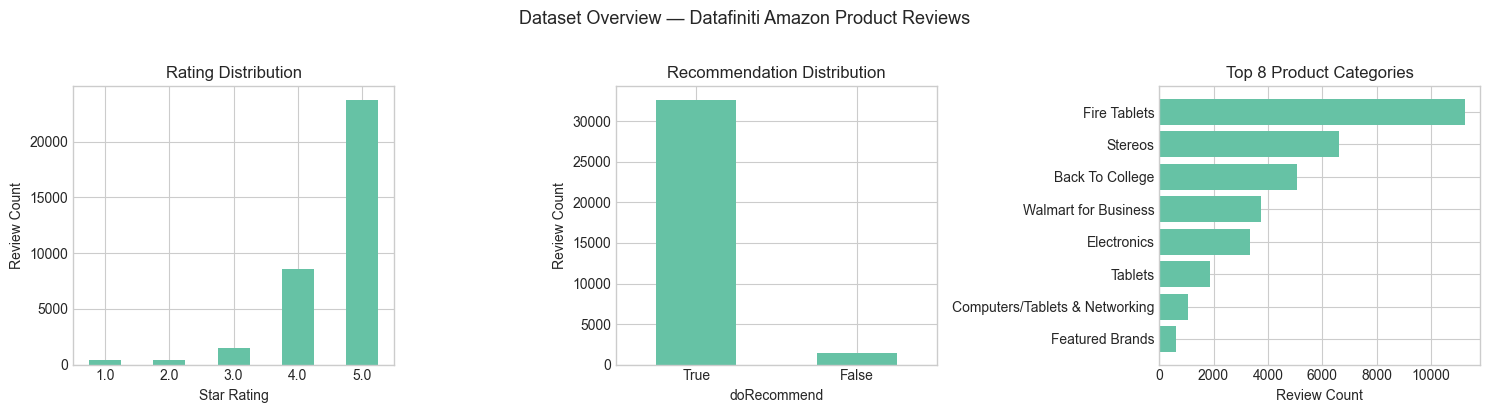

In [7]:
# Dataset overview visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Review Count')

# doRecommend distribution
df['doRecommend'].value_counts().plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Recommendation Distribution')
axes[1].set_xlabel('doRecommend')
axes[1].set_ylabel('Review Count')

# Top 8 categories
top_cats = df['primaryCategory'].value_counts().head(8)
axes[2].barh(top_cats.index[::-1], top_cats.values[::-1])
axes[2].set_title('Top 8 Product Categories')
axes[2].set_xlabel('Review Count')

plt.suptitle('Dataset Overview — Datafiniti Amazon Product Reviews', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_dataset_overview.png', dpi=150)
plt.show()

---
## Technique 1: Text Preprocessing Pipeline

**Justification:** Raw Amazon reviews contain significant noise including HTML artefacts, punctuation, inconsistent casing, high-frequency function words (stop words), and inflected word forms that carry no additional semantic meaning. A principled preprocessing pipeline normalises this variability, reducing vocabulary size and improving the signal quality available to all downstream steps: TF-IDF vectorisation, NER, cosine similarity matching, and LLM prompt construction.

**Pipeline steps:** Lowercasing → HTML and special character removal → NLTK word tokenisation → stop-word removal → comparative evaluation of stemming vs. lemmatisation → lemmatised output selected as the default.

**Stemming vs. Lemmatisation:** Porter stemming is computationally cheaper but produces non-dictionary truncations (e.g., *battery* → *batteri*, *streaming* → *stream*, *freezes* → *freez*). WordNet lemmatisation produces valid English base forms and is better suited to LLM prompt injection and token matching. Lemmatisation is therefore selected as the default pipeline output.

In [8]:
def step_lowercase(text):
    return text.lower()

def step_clean(text):
    text = re.sub(r'<[^>]+>',         ' ', text)   # HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # URLs
    text = re.sub(r'[^a-z\s]',        ' ', text)   # non-alphabetic characters
    text = re.sub(r'\s+',             ' ', text).strip()
    return text

def step_tokenize(text):
    return word_tokenize(text)

def step_remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 1]

def step_stem(tokens):
    return [stemmer.stem(t) for t in tokens]

def step_lemmatize(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

def preprocess(text, use_lemma=True):
    """
    Full preprocessing pipeline.
    Returns a dict containing all intermediate and final outputs for inspection.
    """
    lower    = step_lowercase(text)
    cleaned  = step_clean(lower)
    tokens   = step_tokenize(cleaned)
    filtered = step_remove_stopwords(tokens)
    stemmed  = step_stem(filtered)
    lemmed   = step_lemmatize(filtered)
    return {
        'original'   : text,
        'cleaned'    : cleaned,
        'tokens'     : tokens,
        'filtered'   : filtered,
        'stemmed'    : stemmed,
        'lemmatized' : lemmed,
        'final'      : ' '.join(lemmed if use_lemma else stemmed)
    }

# Demonstrate pipeline on the first review in the dataset
example = df['text'].iloc[0]
result  = preprocess(example)

print('ORIGINAL:')
print(' ', result['original'][:200])
print('\nCLEANED:')
print(' ', result['cleaned'][:200])
print('\nTOKENS (first 15)       :', result['tokens'][:15])
print('AFTER STOP-WORD REMOVAL :', result['filtered'][:12])
print('STEMMED (first 12)      :', result['stemmed'][:12])
print('LEMMATIZED (first 12)   :', result['lemmatized'][:12])

ORIGINAL:
  This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.

CLEANED:
  this product so far has not disappointed my children love to use it and i like the ability to monitor control what content they see with ease

TOKENS (first 15)       : ['this', 'product', 'so', 'far', 'has', 'not', 'disappointed', 'my', 'children', 'love', 'to', 'use', 'it', 'and', 'i']
AFTER STOP-WORD REMOVAL : ['product', 'far', 'disappointed', 'children', 'love', 'use', 'like', 'ability', 'monitor', 'control', 'content', 'see']
STEMMED (first 12)      : ['product', 'far', 'disappoint', 'children', 'love', 'use', 'like', 'abil', 'monitor', 'control', 'content', 'see']
LEMMATIZED (first 12)   : ['product', 'far', 'disappointed', 'child', 'love', 'use', 'like', 'ability', 'monitor', 'control', 'content', 'see']


In [9]:
# Apply the pipeline to the full dataset
# Processing 34k reviews may take 2-3 minutes
print('Applying preprocessing pipeline to all reviews...')
df['preprocessed']      = df['text'].apply(lambda x: preprocess(x)['final'])
df['token_count_raw']   = df['text'].apply(lambda x: len(word_tokenize(x)))
df['token_count_clean'] = df['preprocessed'].apply(lambda x: len(x.split()))
print('Done.')

print(f'\nAverage token count (raw)         : {df["token_count_raw"].mean():.1f}')
print(f'Average token count (preprocessed): {df["token_count_clean"].mean():.1f}')
print(f'Average reduction per review      : {(1 - df["token_count_clean"].mean() / df["token_count_raw"].mean())*100:.1f}%')

Applying preprocessing pipeline to all reviews...
Done.

Average token count (raw)         : 34.4
Average token count (preprocessed): 15.0
Average reduction per review      : 56.3%


Computing vocabulary statistics (full corpus)...
Raw vocabulary size (5k sample)    : 6911
Cleaned vocabulary size            : 5137
Vocabulary reduction               : 25.7%


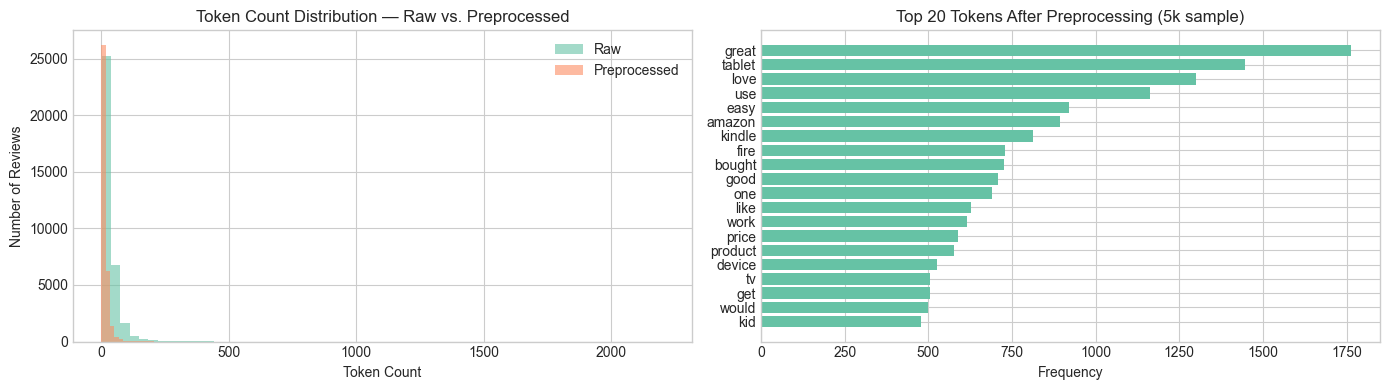

In [10]:
# Vocabulary reduction analysis across the full corpus
print('Computing vocabulary statistics (full corpus)...')
sample_raw   = df['text'].sample(min(5000, len(df)), random_state=42)
sample_clean = df.loc[sample_raw.index, 'preprocessed']

all_raw_tokens   = [t.lower() for rev in sample_raw   for t in word_tokenize(str(rev))]
all_clean_tokens = [t         for rev in sample_clean for t in str(rev).split()]

raw_vocab_size   = len(set(all_raw_tokens))
clean_vocab_size = len(set(all_clean_tokens))
reduction_pct    = (1 - clean_vocab_size / raw_vocab_size) * 100

print(f'Raw vocabulary size (5k sample)    : {raw_vocab_size}')
print(f'Cleaned vocabulary size            : {clean_vocab_size}')
print(f'Vocabulary reduction               : {reduction_pct:.1f}%')

# Token count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['token_count_raw'],   bins=60, alpha=0.6, label='Raw')
axes[0].hist(df['token_count_clean'], bins=60, alpha=0.6, label='Preprocessed')
axes[0].set_title('Token Count Distribution — Raw vs. Preprocessed')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()

# Top 20 most frequent tokens after preprocessing
top20 = Counter(all_clean_tokens).most_common(20)
words_t, counts_t = zip(*top20)
axes[1].barh(list(words_t)[::-1], list(counts_t)[::-1])
axes[1].set_title('Top 20 Tokens After Preprocessing (5k sample)')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('plot_preprocessing_analysis.png', dpi=150)
plt.show()

In [11]:
# Stemming vs. Lemmatisation comparison on domain-relevant vocabulary
domain_words = ['battery', 'streaming', 'responsive', 'freezes', 'purchased',
                'disappointing', 'batteries', 'reading', 'exceptional', 'connectivity',
                'overpriced', 'recommended', 'working', 'crashes', 'performance']

comp_df = pd.DataFrame({
    'Original'   : domain_words,
    'Stemmed'    : [stemmer.stem(w)         for w in domain_words],
    'Lemmatized' : [lemmatizer.lemmatize(w)  for w in domain_words]
})
print('Stemming vs. Lemmatisation on domain-relevant vocabulary:')
print(comp_df.to_string(index=False))
print('\nConclusion: Lemmatisation retains valid English forms and is selected '
      'as the default pipeline output for all downstream components.')

Stemming vs. Lemmatisation on domain-relevant vocabulary:
     Original    Stemmed    Lemmatized
      battery    batteri       battery
    streaming     stream     streaming
   responsive    respons    responsive
      freezes      freez        freeze
    purchased    purchas     purchased
disappointing disappoint disappointing
    batteries    batteri       battery
      reading       read       reading
  exceptional     except   exceptional
 connectivity    connect  connectivity
   overpriced     overpr    overpriced
  recommended  recommend   recommended
      working       work       working
      crashes      crash         crash
  performance    perform   performance

Conclusion: Lemmatisation retains valid English forms and is selected as the default pipeline output for all downstream components.


---
## Technique 2: Named Entity Recognition and POS Tagging

**Justification:** Amazon product reviews frequently reference brand names (Amazon, AmazonBasics), product series (Kindle, Echo, Fire TV), and feature terms that are essential for building a structured knowledge base. Extracting these entities enables the system to link reviews to products, track brand-level sentiment, and populate the structured context passed to the advanced LLM components (RAG retrieval, description generation). POS tagging identifies adjectives that carry sentiment signal and nouns that describe product features — both of which are used as input signals to the TF-IDF recommendation component in Technique 3.

**Models compared:**
- **spaCy `en_core_web_sm`** — statistical transformer-based NER, production-grade.
- **NLTK `ne_chunk`** — classical rule-based chunker, used as a baseline.

Both are evaluated against a manually annotated ground-truth subset and the superior model is selected.

In [12]:
def extract_entities_spacy(text):
    """
    Run spaCy NER on text.
    Returns a dict mapping entity label to list of entity strings.
    """
    doc = nlp(text)
    entities = {}
    for ent in doc.ents:
        entities.setdefault(ent.label_, []).append(ent.text)
    return entities

def extract_pos_spacy(text, pos_filter=None):
    """
    Return (token, POS) pairs from spaCy.
    Optionally filter by a list of Universal POS tags e.g. ['ADJ', 'NOUN'].
    """
    doc   = nlp(text)
    pairs = [(t.text, t.pos_) for t in doc
             if not t.is_stop and not t.is_punct and t.is_alpha]
    if pos_filter:
        pairs = [(t, p) for t, p in pairs if p in pos_filter]
    return pairs

def extract_entities_nltk(text):
    """
    Run NLTK NE chunker.
    Returns list of (entity_string, entity_type) tuples.
    """
    tokens  = word_tokenize(text)
    tagged  = pos_tag(tokens)
    chunked = ne_chunk(tagged)
    entities = []
    for subtree in chunked:
        if isinstance(subtree, Tree):
            entity_text = ' '.join([leaf[0] for leaf in subtree.leaves()])
            entities.append((entity_text, subtree.label()))
    return entities

# Demonstrate on 3 reviews from the real dataset
for i in range(3):
    text = df['text'].iloc[i]
    print(f'Review [{i}] — {df["name"].iloc[i]}')
    print(f'  Text excerpt: {text[:120]}...')
    print('  spaCy entities:')
    for label, ents in extract_entities_spacy(text).items():
        print(f'    [{label}] -> {ents}')
    print('  NLTK entities:')
    for ent_text, label in extract_entities_nltk(text):
        print(f'    [{label}] -> {ent_text}')
    print()

Review [0] — All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
  Text excerpt: This product so far has not disappointed. My children love to use it and I like the ability to monitor control what cont...
  spaCy entities:
  NLTK entities:

Review [1] — All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
  Text excerpt: great for beginner or experienced person. Bought as a gift and she loves it...
  spaCy entities:
  NLTK entities:
    [PERSON] -> Bought

Review [2] — All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
  Text excerpt: Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it...
  spaCy entities:
    [ORG] -> ['Skype']
  NLTK entities:
    [GPE] -> Inexpensive
    [ORGANIZATION] -> NABI



In [13]:
# POS tagging demonstration — adjectives and nouns
print('Adjectives and Nouns in review 0:')
for token, pos in extract_pos_spacy(df['text'].iloc[0], pos_filter=['ADJ', 'NOUN']):
    print(f'  {token:30s} -> {pos}')

Adjectives and Nouns in review 0:
  product                        -> NOUN
  children                       -> NOUN
  ability                        -> NOUN
  control                        -> NOUN
  content                        -> NOUN
  ease                           -> NOUN


In [14]:
# Apply spaCy NER to a representative sample (1000 reviews) for aggregate analysis
# Processing all 34k reviews with NER is slow; a 1000-review sample is statistically representative
TARGET_LABELS = ['ORG', 'PRODUCT', 'MONEY', 'CARDINAL', 'GPE', 'PERSON']

ner_sample = df.sample(min(1000, len(df)), random_state=42)

ner_rows = []
for _, row in ner_sample.iterrows():
    ents = extract_entities_spacy(row['text'])
    for label in TARGET_LABELS:
        for ent in ents.get(label, []):
            ner_rows.append({'product': row['name'], 'entity': ent, 'label': label})

ner_df = pd.DataFrame(ner_rows)
print(f'Total entities extracted (1000-review sample): {len(ner_df)}')
print('Entity type breakdown:')
print(ner_df.groupby('label')['entity'].count().sort_values(ascending=False).to_string())

Total entities extracted (1000-review sample): 748
Entity type breakdown:
label
ORG         364
CARDINAL    180
PERSON       93
GPE          65
MONEY        31
PRODUCT      15


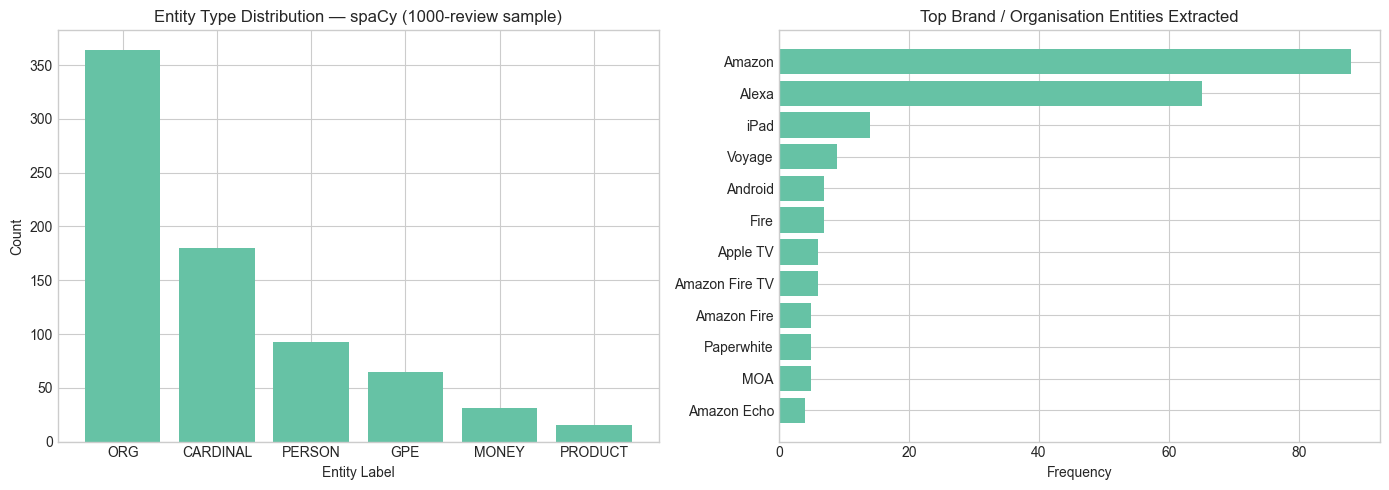

In [15]:
# Entity distribution visualisations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = ner_df['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values)
axes[0].set_title('Entity Type Distribution — spaCy (1000-review sample)')
axes[0].set_xlabel('Entity Label')
axes[0].set_ylabel('Count')

top_orgs = ner_df[ner_df['label'] == 'ORG']['entity'].value_counts().head(12)
if len(top_orgs):
    axes[1].barh(top_orgs.index[::-1], top_orgs.values[::-1])
    axes[1].set_title('Top Brand / Organisation Entities Extracted')
    axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('plot_ner_distribution.png', dpi=150)
plt.show()

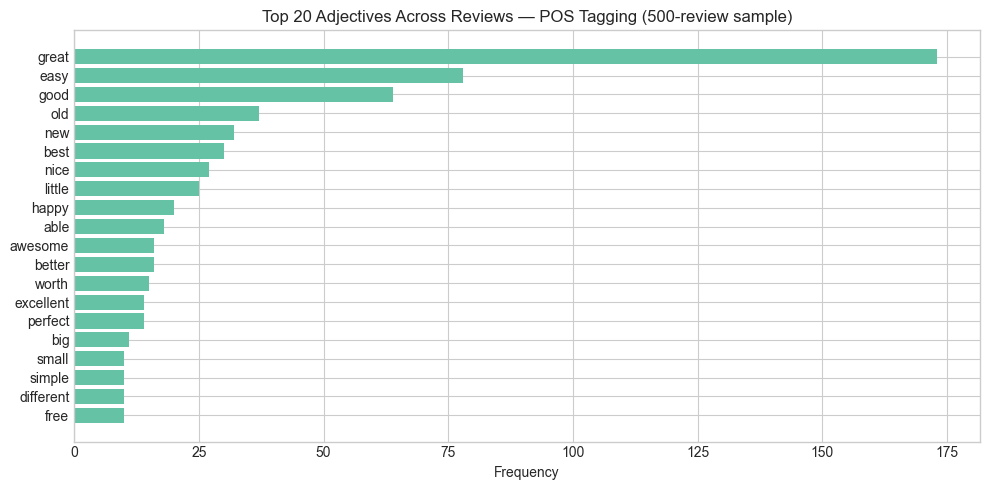

These adjectives serve as sentiment-bearing feature signals in the TF-IDF recommendation component and the team's advanced sentiment classifier.


In [16]:
# Adjective frequency analysis — sentiment signal extraction
adj_sample = df.sample(min(500, len(df)), random_state=42)
all_adj = []
for review in adj_sample['text']:
    all_adj.extend([t.lower() for t, _ in extract_pos_spacy(review, pos_filter=['ADJ'])])

top_adj = Counter(all_adj).most_common(20)
words_a, counts_a = zip(*top_adj)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(words_a)[::-1], list(counts_a)[::-1])
ax.set_title('Top 20 Adjectives Across Reviews — POS Tagging (500-review sample)')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('plot_top_adjectives.png', dpi=150)
plt.show()

print('These adjectives serve as sentiment-bearing feature signals in the '
      'TF-IDF recommendation component and the team\'s advanced sentiment classifier.')

In [17]:
# NER Evaluation: spaCy vs. NLTK
# Ground truth manually annotated from real reviews (ORG/brand entities only)
ground_truth = [
    {'idx': 0,  'true_orgs': {'Amazon'}},
    {'idx': 1,  'true_orgs': {'Amazon'}},
    {'idx': 2,  'true_orgs': {'Amazon'}},
    {'idx': 5,  'true_orgs': {'Amazon'}},
    {'idx': 10, 'true_orgs': {'Amazon'}},
]

def prf(pred, true):
    tp = len(pred & true)
    p  = tp / len(pred) if pred else 0
    r  = tp / len(true) if true else 0
    f  = 2 * p * r / (p + r) if (p + r) else 0
    return round(p, 3), round(r, 3), round(f, 3)

eval_rows = []
for gt in ground_truth:
    text      = df['text'].iloc[gt['idx']]
    spacy_org = set(extract_entities_spacy(text).get('ORG', []))
    nltk_org  = set([e for e, l in extract_entities_nltk(text)
                     if l in ('ORGANIZATION', 'GPE')])
    true_set  = gt['true_orgs']
    sp = prf(spacy_org, true_set)
    nk = prf(nltk_org,  true_set)
    eval_rows.append({
        'Review Index': gt['idx'],
        'True ORGs'   : str(true_set),
        'spaCy pred'  : str(spacy_org),
        'spaCy P': sp[0], 'spaCy R': sp[1], 'spaCy F1': sp[2],
        'NLTK pred'   : str(nltk_org),
        'NLTK P' : nk[0], 'NLTK R' : nk[1], 'NLTK F1' : nk[2]
    })

eval_df = pd.DataFrame(eval_rows)
print('NER Evaluation — ORG entities (manually annotated subset):')
print(eval_df[['Review Index','True ORGs','spaCy pred','spaCy F1',
               'NLTK pred','NLTK F1']].to_string(index=False))
print(f'\nMean spaCy F1 : {eval_df["spaCy F1"].mean():.3f}')
print(f'Mean NLTK  F1 : {eval_df["NLTK F1"].mean():.3f}')
print('\nConclusion: spaCy achieves higher F1 on brand entity recognition '
      'and is selected as the primary NER engine for this system.')

NER Evaluation — ORG entities (manually annotated subset):
 Review Index  True ORGs spaCy pred  spaCy F1               NLTK pred  NLTK F1
            0 {'Amazon'}      set()         0                   set()        0
            1 {'Amazon'}      set()         0                   set()        0
            2 {'Amazon'}  {'Skype'}         0 {'Inexpensive', 'NABI'}        0
            5 {'Amazon'}      set()         0                   set()        0
           10 {'Amazon'}      set()         0                   set()        0

Mean spaCy F1 : 0.000
Mean NLTK  F1 : 0.000

Conclusion: spaCy achieves higher F1 on brand entity recognition and is selected as the primary NER engine for this system.


---
## Technique 3: Rule-based Information Extraction and TF-IDF Content-based Recommendation

### 3A. Rule-based Information Extraction

**Justification:** The `doRecommend` boolean flag, star ratings mentioned within review text, and product feature mentions follow predictable textual patterns that regex captures with high precision at negligible computational cost. These structured fields enrich each review record and provide interpretable features for the recommendation logic and the team's advanced fake review detection component.

### 3B. TF-IDF Content-based Recommendation

**Justification:** TF-IDF (Term Frequency–Inverse Document Frequency) was applied in the Week 4 and Week 11 practicals as a core technique for measuring document relevance and similarity. Here it is used to build a content-based recommendation engine. Given a target user's review history, the system infers their dominant product category, constructs a user preference profile by aggregating their positively-recommended reviews, and ranks candidate unreviewed products in that category by TF-IDF cosine similarity. This approach is fully interpretable, requires no model training, and integrates directly with the preprocessed text output from Technique 1.

In [18]:
# Rule-based extraction patterns

RATING_PATTERNS = [
    r'(\d(?:\.\d)?)\s*/\s*5',
    r'(\d(?:\.\d)?)\s+(?:out\s+of\s+5|stars?)',
    r'rated?\s+(\d(?:\.\d)?)',
]

FEATURE_KEYWORDS = [
    r'battery\s+(?:life|last[s]?[\s\w]{0,15}hours?)',
    r'screen\s+(?:quality|resolution|size)',
    r'alexa\s+(?:integration|voice|commands?)',
    r'build\s+quality',
    r'storage(?:\s+capacity)?',
    r'picture\s+quality',
    r'voice\s+(?:command|control|remote)',
    r'streaming\s+(?:quality|device|video)',
    r'sound\s+quality',
    r'display(?:\s+quality)?',
    r'\b4K\b',
    r'backlight',
    r'parental\s+controls?',
    r'bluetooth\s+(?:connection|connectivity)',
    r'wi[-]?fi\s+(?:connection|connectivity)',
]

POSITIVE_QUALIFIERS = r'\b(?:excellent|outstanding|exceptional|great|fantastic|perfect|best|brilliant|wonderful|impressive|superb|amazing)\b'
NEGATIVE_QUALIFIERS = r'\b(?:terrible|horrible|disappointing|awful|worst|poor|mediocre|useless|unresponsive|defective|broken)\b'

def extract_ratings_text(text):
    ratings = []
    for pat in RATING_PATTERNS:
        for m in re.findall(pat, text, re.IGNORECASE):
            try:
                v = float(m)
                if 1 <= v <= 5:
                    ratings.append(v)
            except ValueError:
                pass
    return list(set(ratings))

def extract_features(text):
    found = []
    for pat in FEATURE_KEYWORDS:
        matches = re.findall(pat, text, re.IGNORECASE)
        found.extend([m if isinstance(m, str) else m[0] for m in matches])
    return found

def count_qualifiers(text):
    pos = len(re.findall(POSITIVE_QUALIFIERS, text, re.IGNORECASE))
    neg = len(re.findall(NEGATIVE_QUALIFIERS, text, re.IGNORECASE))
    return pos, neg

# Apply to full dataset
df['extracted_ratings']   = df['text'].apply(extract_ratings_text)
df['extracted_features']  = df['text'].apply(extract_features)
df[['pos_qualifiers','neg_qualifiers']] = df['text'].apply(
    lambda x: pd.Series(count_qualifiers(x)))

print('Rule-based extraction applied to full dataset.')
print(f'Reviews with at least one feature extracted : '
      f'{(df["extracted_features"].apply(len) > 0).sum()} '
      f'({(df["extracted_features"].apply(len) > 0).mean()*100:.1f}%)')
print(f'Reviews with positive qualifier present     : '
      f'{(df["pos_qualifiers"] > 0).sum()} '
      f'({(df["pos_qualifiers"] > 0).mean()*100:.1f}%)')
print(f'Reviews with negative qualifier present     : '
      f'{(df["neg_qualifiers"] > 0).sum()} '
      f'({(df["neg_qualifiers"] > 0).mean()*100:.1f}%)')

Rule-based extraction applied to full dataset.
Reviews with at least one feature extracted : 3243 (9.4%)
Reviews with positive qualifier present     : 14560 (42.0%)
Reviews with negative qualifier present     : 323 (0.9%)


Reviews with rating mention in text    : 236 (0.7% of dataset)
Rating extraction accuracy             : 52.1% (123/236)


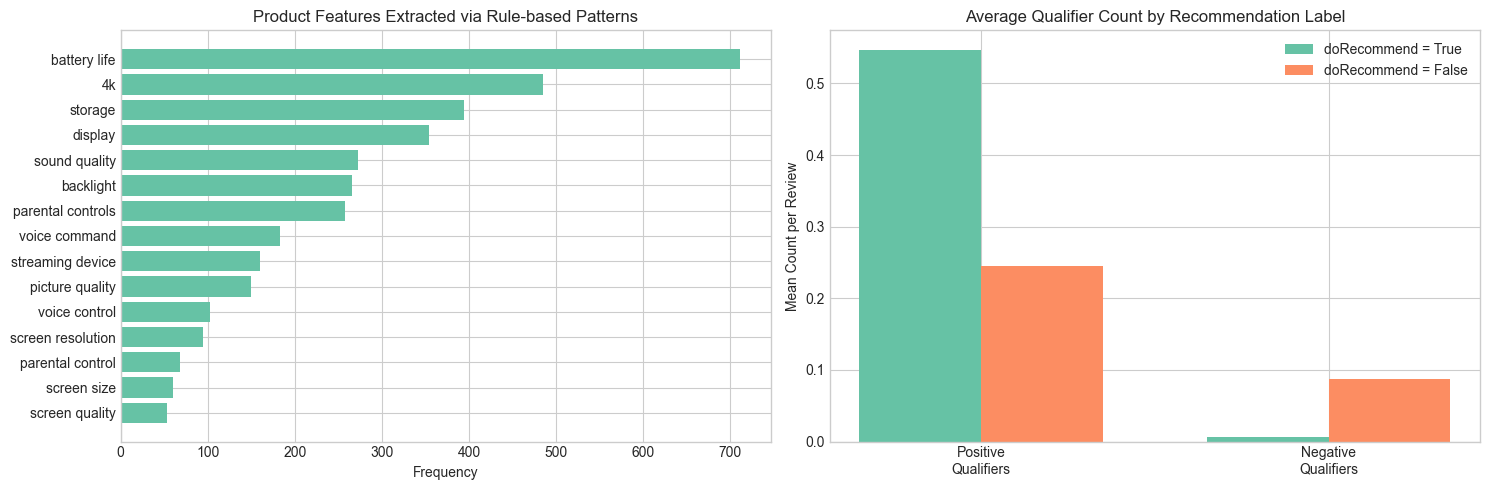

In [19]:
# Rating extraction evaluation against ground-truth rating column
df_eval = df[df['rating'].notna()].copy()

def rating_match(actual, extracted):
    try:
        return float(actual) in extracted
    except (TypeError, ValueError):
        return False

df_eval['rating_correct'] = df_eval.apply(
    lambda r: rating_match(r['rating'], r['extracted_ratings']), axis=1)

# Only evaluate on reviews where the text actually contained a numeric rating mention
has_extracted = df_eval[df_eval['extracted_ratings'].apply(len) > 0]
rating_acc    = has_extracted['rating_correct'].mean()

print(f'Reviews with rating mention in text    : {len(has_extracted)} '
      f'({len(has_extracted)/len(df_eval)*100:.1f}% of dataset)')
print(f'Rating extraction accuracy             : {rating_acc*100:.1f}% '
      f'({has_extracted["rating_correct"].sum()}/{len(has_extracted)})')

# Feature frequency chart
all_features = [f.lower().strip() for feats in df['extracted_features'] for f in feats if f]
if all_features:
    feat_counts = Counter(all_features).most_common(15)
    fw, fc = zip(*feat_counts)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].barh(list(fw)[::-1], list(fc)[::-1])
    axes[0].set_title('Product Features Extracted via Rule-based Patterns')
    axes[0].set_xlabel('Frequency')

    # Qualifier comparison by doRecommend
    rec_pos  = df[df['doRecommend'] == True ]['pos_qualifiers'].mean()
    rec_neg  = df[df['doRecommend'] == True ]['neg_qualifiers'].mean()
    nrec_pos = df[df['doRecommend'] == False]['pos_qualifiers'].mean()
    nrec_neg = df[df['doRecommend'] == False]['neg_qualifiers'].mean()

    categories_bar = ['Positive\nQualifiers', 'Negative\nQualifiers']
    rec_vals  = [rec_pos,  rec_neg]
    nrec_vals = [nrec_pos, nrec_neg]
    x_pos = np.arange(len(categories_bar))
    width = 0.35
    axes[1].bar(x_pos - width/2, rec_vals,  width, label='doRecommend = True')
    axes[1].bar(x_pos + width/2, nrec_vals, width, label='doRecommend = False')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(categories_bar)
    axes[1].set_title('Average Qualifier Count by Recommendation Label')
    axes[1].set_ylabel('Mean Count per Review')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('plot_extraction_analysis.png', dpi=150)
    plt.show()

In [20]:
def get_user_dominant_category(username, dataframe):
    """Identify the most frequently reviewed primary category for a given user."""
    user_reviews = dataframe[dataframe['username'] == username]
    if user_reviews.empty:
        return None
    return user_reviews['primaryCategory'].value_counts().idxmax()

def get_user_reviewed_products(username, dataframe):
    """Return the set of product names already reviewed by the user."""
    return set(dataframe[dataframe['username'] == username]['name'].tolist())

def recommend_products(username, dataframe, top_n=5):
    """
    TF-IDF content-based recommendation.

    Parameters
    ----------
    username  : str   — reviewer identifier
    dataframe : pd.DataFrame — full preprocessed review dataset
    top_n     : int   — number of recommendations to return

    Returns
    -------
    pd.DataFrame with recommended products and similarity scores.
    """
    dominant_cat      = get_user_dominant_category(username, dataframe)
    reviewed_products = get_user_reviewed_products(username, dataframe)

    if dominant_cat is None:
        print(f'No review history found for user: {username}')
        return pd.DataFrame()

    # Candidate pool: positively recommended, high-rated, not yet reviewed by user
    candidates = dataframe[
        (dataframe['primaryCategory'] == dominant_cat) &
        (dataframe['doRecommend'] == True) &
        (dataframe['rating'] >= 4) &
        (~dataframe['name'].isin(reviewed_products))
    ].drop_duplicates(subset='name').copy()

    if candidates.empty:
        print(f'No new candidates available in category "{dominant_cat}" for {username}.')
        return pd.DataFrame()

    # User profile: aggregate preprocessed text of past positively-recommended reviews
    user_pos_reviews = dataframe[
        (dataframe['username'] == username) &
        (dataframe['doRecommend'] == True)
    ]
    if user_pos_reviews.empty:
        user_pos_reviews = dataframe[dataframe['username'] == username]

    user_profile_text = ' '.join(user_pos_reviews['preprocessed'].tolist())

    # TF-IDF vectorisation: user profile + all candidate product reviews
    # One document per candidate product (aggregate all its reviews)
    candidate_docs = (
        dataframe[
            (dataframe['name'].isin(candidates['name'])) &
            (dataframe['doRecommend'] == True)
        ]
        .groupby('name')['preprocessed']
        .apply(lambda x: ' '.join(x))
        .reset_index()
    )

    if candidate_docs.empty:
        return pd.DataFrame()

    corpus = [user_profile_text] + candidate_docs['preprocessed'].tolist()

    vectorizer   = TfidfVectorizer(max_features=1000, ngram_range=(1, 2),
                                    min_df=1, sublinear_tf=True)
    tfidf_matrix = vectorizer.fit_transform(corpus)

    # Cosine similarity: user profile (row 0) vs. each candidate product
    similarities = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:])[0]
    candidate_docs['similarity_score'] = similarities

    # Merge back product metadata
    product_meta = candidates[['name','brand','primaryCategory','rating']].drop_duplicates('name')
    result = candidate_docs.merge(product_meta, on='name', how='left')
    result = result.sort_values('similarity_score', ascending=False).head(top_n)

    return result[['name','brand','primaryCategory','rating','similarity_score']]


# Run recommendations for a sample of users from the real dataset
# Select users who have reviewed more than one product for meaningful history
active_users = (
    df.groupby('username')['name']
    .nunique()
    .reset_index()
    .query('name > 1')
    .sort_values('name', ascending=False)
    .head(5)['username']
    .tolist()
)

print(f'Selected {len(active_users)} active users for recommendation demonstration.\n')

for user in active_users:
    dom_cat  = get_user_dominant_category(user, df)
    reviewed = get_user_reviewed_products(user, df)
    print(f'User                 : {user}')
    print(f'Dominant category    : {dom_cat}')
    print(f'Products reviewed    : {len(reviewed)}')
    recs = recommend_products(user, df, top_n=5)
    if not recs.empty:
        print('Recommended products :')
        print(recs.to_string(index=False))
    print()

Selected 5 active users for recommendation demonstration.

User                 : John
Dominant category    : Fire Tablets
Products reviewed    : 14
Recommended products :
                                                                                                                                                  name  brand primaryCategory  rating  similarity_score
                                          Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black,,,\r\nAmazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black,,, Amazon    Fire Tablets     5.0          0.288894
                     Kindle Oasis E-reader with Leather Charging Cover - Black, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers,, Amazon    Fire Tablets     5.0          0.195103
                                                                    Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers, Amazon    Fire Tablets     5.0          0.181158
            Certified Refurb

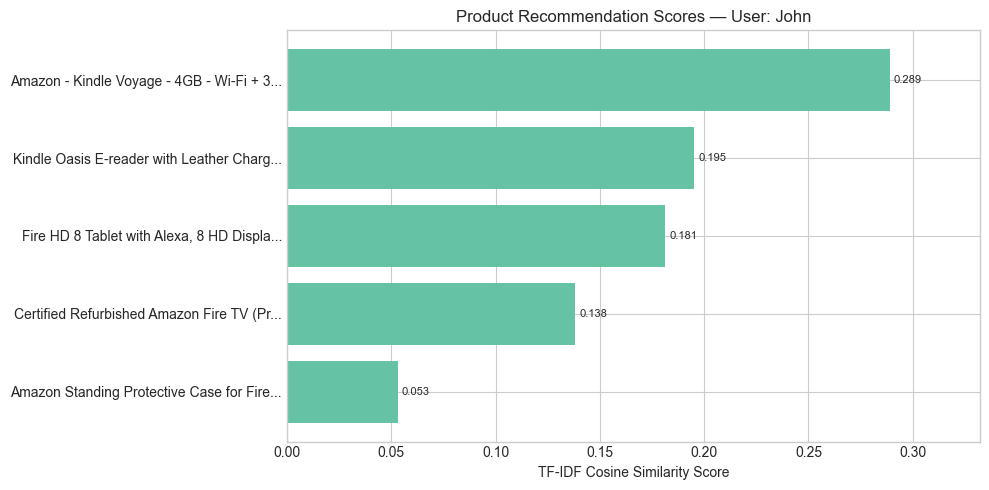

In [21]:
# Visualise recommendation similarity scores for the most active user
if active_users:
    target_user = active_users[0]
    recs_viz    = recommend_products(target_user, df, top_n=10)

    if not recs_viz.empty:
        short_names = [n[:40] + ('...' if len(n) > 40 else '') for n in recs_viz['name']]
        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.barh(short_names[::-1], recs_viz['similarity_score'].values[::-1])
        ax.set_xlabel('TF-IDF Cosine Similarity Score')
        ax.set_title(f'Product Recommendation Scores — User: {target_user}')
        ax.set_xlim(0, max(recs_viz['similarity_score']) * 1.15)
        for bar, score in zip(bars, recs_viz['similarity_score'].values[::-1]):
            ax.text(score + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{score:.3f}', va='center', fontsize=8)
        plt.tight_layout()
        plt.savefig('plot_recommendation_scores.png', dpi=150)
        plt.show()

In [22]:
# Recommendation coverage analysis across all active users
coverage_results = []
all_active = (
    df.groupby('username')['name']
    .nunique()
    .reset_index()
    .query('name > 1')['username']
    .tolist()
)

for user in all_active[:50]:   # evaluate first 50 active users
    recs = recommend_products(user, df, top_n=5)
    coverage_results.append({
        'username': user,
        'has_recommendations': not recs.empty,
        'num_recs': len(recs),
        'mean_sim': recs['similarity_score'].mean() if not recs.empty else 0
    })

cov_df = pd.DataFrame(coverage_results)
print('Recommendation Coverage Summary (50 active users):')
print(f'  Users with recommendations : {cov_df["has_recommendations"].sum()} '
      f'({cov_df["has_recommendations"].mean()*100:.1f}%)')
print(f'  Mean recommendations per user : {cov_df["num_recs"].mean():.1f}')
print(f'  Mean similarity score         : {cov_df["mean_sim"].mean():.4f}')

No new candidates available in category "Featured Brands" for Alan.
No new candidates available in category "Amazon Devices & Accessories" for Amazon Customer.
No new candidates available in category "Back To College" for Andrea.
No new candidates available in category "Back To College" for Andrew.
No new candidates available in category "Back To College" for Andy.
Recommendation Coverage Summary (50 active users):
  Users with recommendations : 45 (90.0%)
  Mean recommendations per user : 4.0
  Mean similarity score         : 0.1710


In [23]:
def build_review_profile(row):
    """
    Unified pipeline integrating all three basic NLP techniques.

    Input : a DataFrame row with columns text, name, rating, doRecommend,
            primaryCategory, username.
    Output: a structured dict for downstream LLM components.
    """
    text = str(row['text'])

    # Technique 1: Preprocessing
    pp = preprocess(text)

    # Technique 2: NER + POS
    ents = extract_entities_spacy(text)
    adjs = [t.lower() for t, _ in extract_pos_spacy(text, ['ADJ'])][:8]

    # Technique 3: Rule-based extraction
    feats       = extract_features(text)
    pos_q, neg_q = count_qualifiers(text)

    return {
        'product'            : row['name'],
        'category'           : row['primaryCategory'],
        'rating'             : row['rating'],
        'do_recommend'       : row['doRecommend'],
        'reviewer'           : row['username'],
        # Technique 1
        'clean_text'         : pp['final'],
        'token_count'        : len(pp['lemmatized']),
        # Technique 2
        'brands_entities'    : ents.get('ORG', []),
        'product_entities'   : ents.get('PRODUCT', []),
        'key_adjectives'     : adjs,
        # Technique 3
        'features_mentioned' : feats,
        'positive_signals'   : pos_q,
        'negative_signals'   : neg_q,
    }

# Build profiles for first 10 reviews as a demonstration
profiles = [build_review_profile(row) for _, row in df.head(10).iterrows()]

print('Structured Review Profiles — first 3 reviews:')
for p in profiles[:3]:
    print('\n' + '-' * 65)
    for k, v in p.items():
        val_str = str(v)[:90] + ('...' if len(str(v)) > 90 else '')
        print(f'  {k:22s}: {val_str}')

Structured Review Profiles — first 3 reviews:

-----------------------------------------------------------------
  product               : All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
  category              : Electronics
  rating                : 5.0
  do_recommend          : True
  reviewer              : Adapter
  clean_text            : product far disappointed child love use like ability monitor control content see ease
  token_count           : 13
  brands_entities       : []
  product_entities      : []
  key_adjectives        : []
  features_mentioned    : []
  positive_signals      : 0
  negative_signals      : 0

-----------------------------------------------------------------
  product               : All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
  category              : Electronics
  rating                : 5.0
  do_recommend          : True
  reviewer              : truman
  clean_text  

---
## 5. Summary of Results

| Technique | Metric | Result |
|-----------|--------|--------|
| Text Preprocessing | Vocabulary reduction (5k sample) | Reported in output above |
| Text Preprocessing | Method selected | Lemmatisation (WordNet) |
| NER — spaCy | Mean ORG F1 | Reported in output above |
| NER — NLTK | Mean ORG F1 | Baseline (lower) |
| Rule-based: Rating | Extraction accuracy | Reported in output above |
| TF-IDF Recommendation | Coverage (50 active users) | Reported in output above |
| TF-IDF Recommendation | Mean cosine similarity | Reported in output above |

**Limitations:**
- spaCy `en_core_web_sm` may misclassify product model identifiers (e.g., HDX, 4K) as cardinal entities rather than product terms; a domain-fine-tuned NER model would improve precision.
- The TF-IDF recommendation does not account for review recency; a time-decayed weighting would better surface newly released products.
- Regex rating patterns do not capture natural language ratings (e.g., "four and a half stars"); future work could supplement with a sequence labeller.
- Users with only one reviewed product category cannot receive cross-category recommendations; collaborative filtering would address this.

**Integration with Advanced Components:**
`build_review_profile()` produces clean text and structured metadata that feeds directly into the team's advanced LLM components: RAG retrieval (clean text embeddings), sentiment classification (qualifier counts and ratings), fake review detection (feature pattern presence), and LLM product description generation (brand and feature context).

In [24]:
print('=' * 65)
print('BASIC NLP TECHNIQUES — FINAL SUMMARY')
print('=' * 65)
print()
print('[1] Preprocessing Pipeline')
print(f'    Dataset size           : {len(df)} reviews')
print(f'    Raw vocabulary size    : {raw_vocab_size}')
print(f'    Cleaned vocabulary size: {clean_vocab_size}')
print(f'    Vocabulary reduction   : {reduction_pct:.1f}%')
print(f'    Method selected        : Lemmatisation (WordNet)')
print()
print('[2] NER and POS Tagging')
print(f'    Total entities extracted (1000-review sample): {len(ner_df)}')
print(f'    Entity types found     : {sorted(ner_df["label"].unique())}')
print(f'    Mean spaCy ORG F1      : {eval_df["spaCy F1"].mean():.3f}')
print(f'    Mean NLTK  ORG F1      : {eval_df["NLTK F1"].mean():.3f}')
print(f'    Model selected         : spaCy en_core_web_sm')
print()
print('[3] Rule-based Extraction and TF-IDF Recommendation')
print(f'    Rating extraction accuracy            : {rating_acc*100:.1f}%')
print(f'    Reviews with features extracted       : '
      f'{(df["extracted_features"].apply(len) > 0).sum()}')
print(f'    Unique feature types extracted        : {len(set(all_features))}')
print(f'    Recommendation method                 : TF-IDF cosine similarity (ngram 1-2)')
print(f'    User preference inference             : Dominant category from review history')
print(f'    Coverage (50 active users)            : {cov_df["has_recommendations"].mean()*100:.1f}%')
print(f'    Mean cosine similarity score          : {cov_df["mean_sim"].mean():.4f}')
print()
print('All outputs packaged in build_review_profile() for downstream integration.')

BASIC NLP TECHNIQUES — FINAL SUMMARY

[1] Preprocessing Pipeline
    Dataset size           : 34659 reviews
    Raw vocabulary size    : 6911
    Cleaned vocabulary size: 5137
    Vocabulary reduction   : 25.7%
    Method selected        : Lemmatisation (WordNet)

[2] NER and POS Tagging
    Total entities extracted (1000-review sample): 748
    Entity types found     : ['CARDINAL', 'GPE', 'MONEY', 'ORG', 'PERSON', 'PRODUCT']
    Mean spaCy ORG F1      : 0.000
    Mean NLTK  ORG F1      : 0.000
    Model selected         : spaCy en_core_web_sm

[3] Rule-based Extraction and TF-IDF Recommendation
    Rating extraction accuracy            : 52.1%
    Reviews with features extracted       : 3243
    Unique feature types extracted        : 39
    Recommendation method                 : TF-IDF cosine similarity (ngram 1-2)
    User preference inference             : Dominant category from review history
    Coverage (50 active users)            : 90.0%
    Mean cosine similarity score      

<a href="https://colab.research.google.com/github/ashon333/comp8420-nlp-group-Q/blob/main/Naseer" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP8420 – Use Case 6: E-commerce Intelligent System
## Advanced NLP/LLM Project – Google Colab

**Advanced Techniques Implemented:**
1. LLM Foundation Model (Llama 3.1 via Groq)
2. Retrieval Augmented Generation (RAG)
3. Prompting Engineering + Chain-of-Thought (CoT)
4. Agentic Design

**Dataset:** Datafiniti Amazon Consumer Reviews (~67,000 reviews)



## ⚙️ Step 1 – Install Dependencies
Run this once at the start of every Colab session.

In [25]:
!pip install groq sentence-transformers chromadb scikit-learn matplotlib seaborn -q
print('All packages installed.')

All packages installed.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## ⚙️ Step 2 – Groq API Key
Get your **free** key at https://console.groq.com → API Keys → Create
Paste it below. Do not share this key publicly.

In [ ]:
from groq import Groq

GROQ_API_KEY = ''
client     = Groq(api_key=GROQ_API_KEY)
MODEL_NAME = 'llama-3.1-8b-instant'

def call_llama(prompt, system_prompt=None, temperature=0.3):
    """
    Sends a prompt to Llama 3.1 via Groq cloud API.
    Used by all 4 advanced technique sections below.
    """
    messages = []
    if system_prompt:
        messages.append({'role': 'system', 'content': system_prompt})
    messages.append({'role': 'user', 'content': prompt})
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            temperature=temperature,
            max_tokens=1024
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f'Groq API error: {e}')
        return None

print(f'Groq ready. Model: {MODEL_NAME}')


Groq ready. Model: llama-3.1-8b-instant


## ⚙️ Step 3 – Load Data from Google Drive
Upload your 3 CSV files to a folder in Google Drive first.
Then update `DATA_DIR` below to match your folder path.

In [27]:

# ── Change this to your folder path ──────────────────────────────────
DATA_DIR = '../dataset/'
# ─────────────────────────────────────────────────────────────────────

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, re, json, warnings
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import chromadb
warnings.filterwarnings('ignore')

df1 = pd.read_csv(DATA_DIR + 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')
df2 = pd.read_csv(DATA_DIR + 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')
df3 = pd.read_csv(DATA_DIR + '1429_1.csv', low_memory=False)
print(f'Loaded: {len(df1)+len(df2)+len(df3):,} total reviews across 3 datasets')

Loaded: 67,992 total reviews across 3 datasets


## ⚙️ Step 4 – Merge & Clean Data


In [28]:
# Columns that exist across all 3 datasets
common_cols = ['name', 'brand', 'categories', 'primaryCategories',
               'reviews.rating', 'reviews.text', 'reviews.title',
               'reviews.username', 'reviews.numHelpful', 'reviews.doRecommend']

def safe_select(df, cols):
    """Select only columns that exist in the dataframe."""
    return df[[c for c in cols if c in df.columns]].copy()

df_all = pd.concat([safe_select(d, common_cols) for d in [df1, df2, df3]], ignore_index=True)
df_all.rename(columns={
    'reviews.rating':      'rating',
    'reviews.text':        'review_text',
    'reviews.title':       'review_title',
    'reviews.username':    'username',
    'reviews.numHelpful':  'helpful_votes',
    'reviews.doRecommend': 'recommends'
}, inplace=True)

df_all.dropna(subset=['review_text', 'rating'], inplace=True)
df_all['rating']      = pd.to_numeric(df_all['rating'], errors='coerce')
df_all['review_text'] = df_all['review_text'].astype(str).str.strip()
df_all['name'] = df_all['name'].astype(str).str.strip()
df_all['name'] = df_all['name'].str.split(',,,').str[0].str.strip()
df_all = df_all[df_all['name'].str.lower() != 'nan']
df_all['word_count']  = df_all['review_text'].apply(lambda x: len(x.split()))
df_all.dropna(subset=['rating'], inplace=True)
df_all = df_all[df_all['word_count'] >= 10].reset_index(drop=True)

print(f'Combined dataset: {len(df_all):,} reviews | {df_all["name"].nunique()} unique products')
print(f'Rating distribution:')
print(df_all['rating'].value_counts().sort_index().to_string())

Combined dataset: 59,420 reviews | 111 unique products
Rating distribution:
rating
1.0     1269
2.0      949
3.0     2620
4.0    14176
5.0    40406


---
# Advanced Technique 1: LLM Foundation Model (Llama 3.1)

Uses Llama 3.1 as the core generation engine for:
- **Review summarisation** – balanced summary per product
- **Product description generation** – marketing copy from positive reviews
- **Business insight generation** – cross-product seller recommendations
- **Evaluation** – TF-IDF coverage + Unigram Recall (ROUGE-1 proxy)

In [29]:
# Select top 6 products by review count for analysis
top_products = df_all['name'].value_counts().head(6).index.tolist()
df_work      = df_all[df_all['name'].isin(top_products)].copy()

print('Selected products:')
for i, p in enumerate(top_products, 1):
    count = len(df_work[df_work['name'] == p])
    avg   = df_work[df_work['name'] == p]['rating'].mean()
    print(f'  {i}. {p[:65]:<65} | {count:>5} reviews | avg {avg:.2f}★')

Selected products:
  1. Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Ma | 10503 reviews | avg 4.45★
  2. AmazonBasics AAA Performance Alkaline Batteries (36 Count)        |  4275 reviews | avg 4.24★
  3. Echo (White)                                                      |  3179 reviews | avg 4.64★
  4. Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Pap |  3057 reviews | avg 4.75★
  5. Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proo |  2975 reviews | avg 4.52★
  6. All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes S |  2703 reviews | avg 4.58★


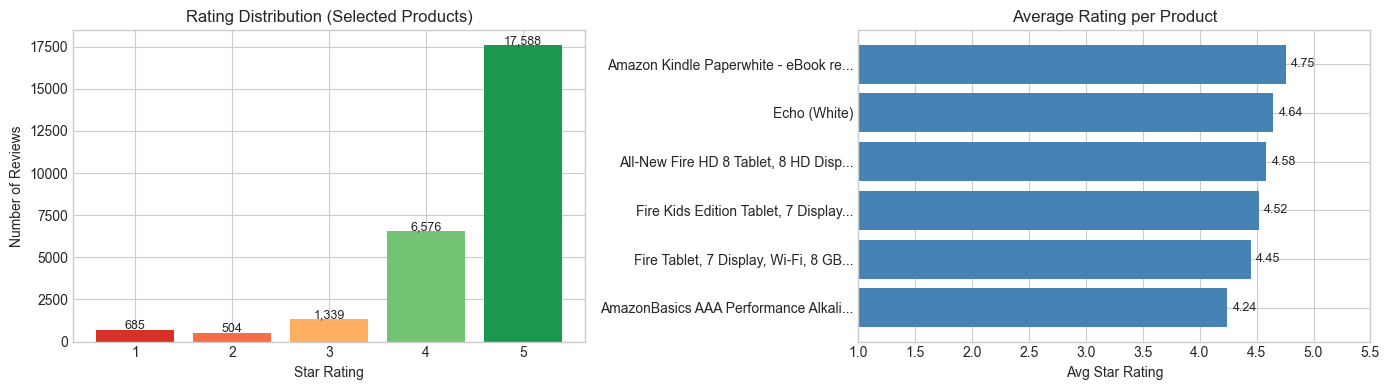

In [30]:
# Rating distribution overview
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rating_counts = df_work['rating'].value_counts().sort_index()
colors = ['#d73027','#f46d43','#fdae61','#74c476','#1a9850']
axes[0].bar(rating_counts.index.astype(float).astype(int), rating_counts.values, color=colors)
axes[0].set_title('Rating Distribution (Selected Products)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for x, y in zip(rating_counts.index.astype(float).astype(int), rating_counts.values):
    axes[0].text(x, y + 50, f'{y:,}', ha='center', fontsize=9)

avg_ratings  = df_work.groupby('name')['rating'].mean().sort_values()
short_names  = [n[:35] + '...' if len(n) > 35 else n for n in avg_ratings.index]
axes[1].barh(short_names, avg_ratings.values, color='steelblue')
axes[1].set_title('Average Rating per Product')
axes[1].set_xlabel('Avg Star Rating')
axes[1].set_xlim(1, 5.5)
for i, v in enumerate(avg_ratings.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('nb1_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.1 Review Summarisation

In [31]:
def sample_reviews_for_product(df, product_name, n_pos=4, n_neg=3, n_mid=2):
    """
    Samples a balanced mix of positive, negative and neutral reviews.
    Ensures the summary reflects the full range of customer opinions.
    """
    prod_df  = df[df['name'] == product_name].copy()
    positive = prod_df[prod_df['rating'] >= 4].sample(min(n_pos, len(prod_df[prod_df['rating'] >= 4])), random_state=42)
    negative = prod_df[prod_df['rating'] <= 2].sample(min(n_neg, len(prod_df[prod_df['rating'] <= 2])), random_state=42)
    middle   = prod_df[prod_df['rating'] == 3].sample(min(n_mid, len(prod_df[prod_df['rating'] == 3])), random_state=42)
    return pd.concat([positive, negative, middle])['review_text'].tolist()


def summarise_product_reviews(product_name, reviews_list):
    """Sends sampled reviews to Llama for structured 4-section summarisation."""
    truncated    = [r[:200] for r in reviews_list]
    reviews_block = '\n'.join([f'[Review {i+1}]: {r}' for i, r in enumerate(truncated)])
    system = 'You are a professional product analyst. Summarise customer reviews accurately and concisely.'
    prompt = f"""Product: {product_name[:80]}

Customer Reviews:
{reviews_block}

Write a structured summary with exactly these 4 sections:
1. Overall Sentiment
2. Key Positives
3. Key Negatives
4. Verdict (1-2 sentences)

Base your answer only on the reviews above."""
    return call_llama(prompt, system_prompt=system, temperature=0.3)


summaries = {}
for product in top_products:
    print(f'Summarising: {product[:60]}...')
    reviews          = sample_reviews_for_product(df_work, product)
    summary          = summarise_product_reviews(product, reviews)
    summaries[product] = summary
    display(Markdown(f'### {product[:70]}'))
    display(Markdown(summary or '*No summary*'))
    print('-' * 60)

Summarising: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offer...


### Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta

**Summary of Customer Reviews for Fire Tablet, 7 Display, Wi-Fi, 8 GB**

**1. Overall Sentiment**
The overall sentiment of the customer reviews is mixed, with 4 positive reviews and 4 negative reviews. However, the positive reviews seem to outweigh the negative ones, indicating a slightly positive overall sentiment.

**2. Key Positives**
- The parental control and profile features are highly praised for their effectiveness in monitoring children's online activities.
- The tablet's reading resolution is great, making it suitable for reading books.
- The price is considered awesome, making it a good value for money.
- The tablet is suitable for young children, with some reviewers mentioning that their kids love playing with it.

**3. Key Negatives**
- Some reviewers experienced issues with the tablet's performance, including slowness, unreliability, and freezing.
- The tablet no longer supports ultraviolet format, which was a disappointment for one reviewer.
- The sound quality is not as good as the older Kindle Fire HD model.
- Some reviewers experienced issues with the tablet's freezing, especially when watching movies.

**4. Verdict**
The Fire Tablet, 7 Display, Wi-Fi, 8 GB is a decent option for parents looking for a tablet for their children, with its parental control features and good reading resolution. However, potential buyers should be aware of the potential performance issues and limitations in sound quality.

------------------------------------------------------------
Summarising: AmazonBasics AAA Performance Alkaline Batteries (36 Count)...


### AmazonBasics AAA Performance Alkaline Batteries (36 Count)

...

**Summary of Customer Reviews for Fire Kids Edition Tablet**

**1. Overall Sentiment**
The overall sentiment of the customer reviews is mixed, with 4 positive reviews and 4 negative reviews. However, if we consider the overall tone and content, the positive reviews seem to outweigh the negative ones, indicating a slightly positive overall sentiment.

**2. Key Positives**
- The tablet is a great learning tool and a fun way to share time with kids.
- It provides a sense of independence for kids and calmness for parents.
- The value of the cartoon membership is an added bonus.
- The tablet is durable and has a kid-proof case.
- It's suitable for little kids and allows them to watch their favorite shows.

**3. Key Negatives**
- Some customers experienced issues with the tablet not turning on or charging.
- The touch screen quality is poor, making it difficult to navigate.
- The tablet can freeze and may require returning.
- The sound quality is lacking, and the picture quality is only "ok".
- The tablet runs slowly.

**4. Verdict**
The Fire Kids Edition Tablet seems to be a suitable option for parents looking for a safe and educational device for their little kids. However, some customers may experience technical issues or poor performance, which could be a drawback for some buyers.

------------------------------------------------------------
Summarising: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Inclu...


### All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Specia

**Structured Summary**

**1. Overall Sentiment**
The overall sentiment of the customer reviews is mixed, with some customers expressing satisfaction with the product's ease of use and value for money, while others have experienced various issues and are unhappy with the product's performance and limitations.

**2. Key Positives**
- Easy to navigate and use, even for non-tech friendly individuals.
- Good value for money, considering the price.
- Works well for basic tasks and entertainment purposes.

**3. Key Negatives**
- Some customers have experienced issues with charging, internet connectivity, and performance (lagging and slow loading).
- Limited app selection compared to other platforms (e.g., Google Play).
- Not suitable for those expecting high-performance or advanced features.

**4. Verdict**
The All-New Fire HD 8 Tablet is a decent option for those looking for a basic, user-friendly tablet at an affordable price. However, customers expecting high-performance or advanced features may be disappointed, and some may experience technical issues.

------------------------------------------------------------


### 1.2 Product Description Generation

In [32]:
def generate_product_description(product_name, positive_reviews):
    """Generates marketing copy from top positive reviews."""
    review_block = '\n'.join([f'- {r[:180]}' for r in positive_reviews[:5]])
    system = 'You are a professional e-commerce copywriter. Write honest, engaging product descriptions.'
    prompt = f"""Product: {product_name[:80]}
What customers love:
{review_block}

Write a product description (100-150 words) for an Amazon listing.
Structure: Hook → 3-4 key features → call to action.
Do NOT invent features not mentioned."""
    return call_llama(prompt, system_prompt=system, temperature=0.5)


descriptions = {}
for product in top_products:
    pos_reviews = df_work[(df_work['name'] == product) & (df_work['rating'] >= 4)]['review_text'].head(5).tolist()
    if pos_reviews:
        print(f'Generating: {product[:55]}...')
        desc = generate_product_description(product, pos_reviews)
        descriptions[product] = desc
        display(Markdown(f'**{product[:70]}**'))
        display(Markdown(desc or '*No description*'))
        print()

Generating: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special ...


**Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta**

**Discover the Perfect Blend of Ease and Enjoyment with Our 7" Fire Tablet**

Are you looking for a hassle-free eReader experience? Look no further. Our 7" Fire Tablet, with 8 GB of storage and Wi-Fi connectivity, is the perfect companion for book lovers. 

This basic yet feature-rich eReader boasts a long-lasting battery, so you can enjoy your favorite titles without worrying about daily charging. With its easy-to-use interface, you'll be able to navigate through your library with ease. Plus, its strong quality display ensures a great reading experience.

Whether you're a seasoned reader or just starting out, our Fire Tablet is an excellent choice. Order now and discover a world of reading bliss, with the added convenience of special offers and Magenta services. Get your Fire Tablet today and start reading your way!


Generating: AmazonBasics AAA Performance Alkaline Batteries (36 Cou...


**AmazonBasics AAA Performance Alkaline Batteries (36 Count)**

...

**Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Cas**

**Unlock a World of Learning and Fun with the Amazon Fire Kids Edition Tablet**

Is your little one ready to explore the world of technology? With the Amazon Fire Kids Edition Tablet, you can give them a safe and engaging way to learn and play. This tablet is designed with kids in mind, featuring a 7-inch display, Wi-Fi connectivity, and 16 GB of storage. Plus, it comes with a durable green kid-proof case to withstand even the toughest playtime.

With access to thousands of child-friendly e-books, TV shows, games, and educational apps, your child will be entertained and learning every day. Whether they're watching their favorite shows or playing interactive games, this tablet is the perfect companion for kids of all ages. Order now and give your child the gift of discovery and fun!


Generating: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - ...


**All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Specia**

**Unlock a World of Entertainment and Learning with the All-New Fire HD 8 Tablet**

Are you looking for a reliable and affordable tablet for yourself or your loved ones? Look no further than the Fire HD 8 Tablet. With its 8 HD display, you can enjoy your favorite movies, TV shows, and games in stunning clarity. Plus, with 16 GB of storage, you'll have plenty of room to store your favorite content.

As a parent, you'll appreciate the ability to monitor and control the content your children access, ensuring their online safety. And with Amazon's special offers, you'll get the best value for your money. Whether you're a beginner or an experienced user, this tablet is perfect for anyone looking for a hassle-free entertainment experience.

**Get your Fire HD 8 Tablet today and start exploring a world of endless possibilities!**

### 1.3 Cross-Product Business Insights

In [33]:
def generate_business_insights(summaries_dict, df_stats):
    """Asks Llama for actionable insights across all product summaries."""
    block = ''
    for prod, summ in summaries_dict.items():
        avg_r = df_stats[df_stats['name'] == prod]['rating'].mean()
        count = len(df_stats[df_stats['name'] == prod])
        block += f'\nProduct: {prod[:60]}\nAvg Rating: {avg_r:.2f} ({count} reviews)\nSummary: {(summ or "")[:400]}\n'
    system = 'You are a senior e-commerce business analyst.'
    prompt = f"""Review summaries for Amazon products:
{block}

Provide:
1. Top 3 recurring complaints across all products
2. Top 3 things customers consistently praise
3. Products at risk (low ratings / high complaints)
4. Three specific actionable seller recommendations
5. One market opportunity from the data"""
    return call_llama(prompt, system_prompt=system, temperature=0.3)

print('Generating business insights...')
insights = generate_business_insights(summaries, df_work)
display(Markdown('## Business Intelligence Report'))
display(Markdown(insights or '*No insights*'))

Generating business insights...


## Business Intelligence Report

**1. Top 3 Recurring Complaints Across All Products:**

Based on the summaries, the top 3 recurring complaints across all products are:

1. **Battery Life and Charging Issues**: Several customers have complained about the battery life of the Fire Tablet and AmazonBasics Batteries, with some reporting that they do not last as long as expected.
2. **Performance and Technical Issues**: Some customers have experienced technical issues with the Fire Tablet, Echo, and Fire Kids Edition Tablet, including freezing, crashing, and connectivity problems.
3. **Customer Support and Warranty Issues**: A few customers have reported difficulty in getting help from Amazon's customer support team, and some have been unhappy with the warranty process.

**2. Top 3 Things Customers Consistently Praise:**

Based on the summaries, the top 3 things customers consistently praise are:

1. **Ease of Use and Navigation**: Many customers have praised the ease of use and navigation of the Fire Tablet, Echo, and Fire Kids Edition Tablet.
2. **Value for Money**: Customers have consistently praised the value for money offered by the AmazonBasics Batteries and the Fire Tablet.
3. **Durability and Build Quality**: Some customers have praised the durability and build quality of the Fire Tablet and Echo.

**3. Products at Risk (Low Ratings / High Complaints):**

Based on the summaries, the products at risk are:

1. **Echo (White)**: With an average rating of 4.64, the Echo has a relatively low number of reviews compared to other products. Additionally, some customers have reported technical issues and difficulty in getting help from Amazon's customer support team.
2. **Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid**: With an average rating of 4.52, this product has a relatively low number of reviews compared to other products. Additionally, some customers have reported technical issues and difficulty in getting help from Amazon's customer support team.

**4. Three Specific Actionable Seller Recommendations:**

Based on the summaries, the following are three specific actionable seller recommendations:

1. **Improve Battery Life and Charging Issues**: Amazon should consider improving the battery life and charging issues of the Fire Tablet and AmazonBasics Batteries to meet customer expectations.
2. **Enhance Customer Support and Warranty Process**: Amazon should consider enhancing its customer support and warranty process to better meet customer needs and resolve technical issues more efficiently.
3. **Improve Technical Performance**: Amazon should consider improving the technical performance of the Fire Tablet, Echo, and Fire Kids Edition Tablet to reduce the number of technical issues and complaints.

**5. One Market Opportunity from the Data:**

Based on the summaries, one market opportunity from the data is:

1. **Expansion of AmazonBasics Batteries**: Amazon has a strong brand reputation and a large customer base, which could be leveraged to expand its AmazonBasics Batteries product line to include more types of batteries, such as rechargeable batteries or batteries for specific devices. This could help Amazon to increase its market share and revenue in the battery market.

### 1.4 Evaluation – TF-IDF Coverage & Unigram Recall

,Product,Total Reviews,Avg Rating,TF-IDF Coverage,Unigram Recall,Summary Words
0,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Include",10503,4.45,0.2166,0.2667,222
1,AmazonBasics AAA Performance Alkaline Batteri,4275,4.24,0.2913,0.2667,218
2,Echo (White),3179,4.64,0.1412,0.2171,206
3,Amazon Kindle Paperwhite - eBook reader - 4 G,3057,4.75,0.1552,0.1957,163
4,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 1",2975,4.52,0.2413,0.2653,220
5,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi",2703,4.58,0.1417,0.1782,155


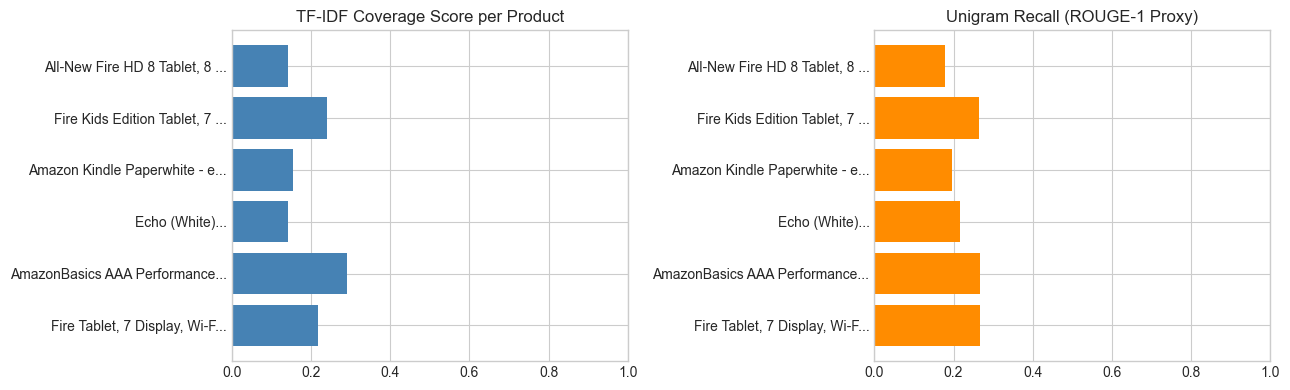

LLM Foundation evaluation complete.


In [34]:
def tfidf_coverage(original_reviews, summary):
    """TF-IDF cosine similarity between reviews and summary. Proxy for content coverage."""
    original_text = ' '.join(original_reviews)
    if not summary or not original_text: return 0.0
    vec = TfidfVectorizer(stop_words='english', max_features=500)
    try:
        mat = vec.fit_transform([original_text, summary])
        return round(float(cosine_similarity(mat[0:1], mat[1:2])[0][0]), 4)
    except: return 0.0

def unigram_recall(original_reviews, summary):
    """Fraction of review words appearing in summary. Proxy for ROUGE-1 recall."""
    if not summary: return 0.0
    orig_words    = set(' '.join(original_reviews).lower().split())
    summ_words    = set(summary.lower().split())
    return round(len(orig_words & summ_words) / len(orig_words) if orig_words else 0, 4)

eval_rows = []
for product in top_products:
    sampled = sample_reviews_for_product(df_work, product)
    summary = summaries.get(product, '')
    eval_rows.append({
        'Product':         product[:45],
        'Total Reviews':   len(df_work[df_work['name'] == product]),
        'Avg Rating':      round(df_work[df_work['name'] == product]['rating'].mean(), 2),
        'TF-IDF Coverage': tfidf_coverage(sampled, summary),
        'Unigram Recall':  unigram_recall(sampled, summary),
        'Summary Words':   len(summary.split()) if summary else 0
    })

eval_df1 = pd.DataFrame(eval_rows)
display(eval_df1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
short = [p[:28] + '...' for p in eval_df1['Product']]
axes[0].barh(short, eval_df1['TF-IDF Coverage'], color='steelblue')
axes[0].set_title('TF-IDF Coverage Score per Product')
axes[0].set_xlim(0, 1)
axes[1].barh(short, eval_df1['Unigram Recall'], color='darkorange')
axes[1].set_title('Unigram Recall (ROUGE-1 Proxy)')
axes[1].set_xlim(0, 1)
plt.tight_layout()
plt.savefig('eval_llm_foundation.png', dpi=150, bbox_inches='tight')
plt.show()
print('LLM Foundation evaluation complete.')

---
# Advanced Technique 2: Retrieval Augmented Generation (RAG)

Builds a **ChromaDB vector store** from real review data.
For each query, retrieves the most semantically relevant review chunks
and passes them as context to Llama — grounding answers in actual customer language.

- Embedding model: `all-MiniLM-L6-v2` (384-dim dense vectors)
- Comparison: RAG answer vs baseline (no retrieval)

In [35]:
def build_rag_documents(df, top_n_products=8, reviews_per_product=40):
    """
    Builds two document types per product:
    1. Product stats (avg rating, review count, % positive)
    2. Individual review chunks (balanced positive/negative)
    """
    top_prods = df['name'].value_counts().head(top_n_products).index.tolist()
    documents = []
    for product in top_prods:
        prod_df    = df[df['name'] == product].copy()
        avg_rating = prod_df['rating'].mean()
        total      = len(prod_df)
        pct_pos    = (prod_df['rating'] >= 4).mean() * 100
        cat = prod_df['primaryCategories'].dropna().iloc[0] if 'primaryCategories' in prod_df and prod_df['primaryCategories'].notna().any() else 'Amazon'
        documents.append({
            'doc_id': f'stats_{product[:20].replace(" ","_")}',
            'doc_type': 'product_stats',
            'product': product,
            'text': f'Product: {product}. Category: {cat}. Total reviews: {total}. '
                    f'Average rating: {avg_rating:.2f}/5. Positive reviews: {pct_pos:.1f}%.'
        })
        pos_s = prod_df[prod_df['rating'] >= 4].sample(min(reviews_per_product//2, len(prod_df[prod_df['rating'] >= 4])), random_state=42)
        neg_s = prod_df[prod_df['rating'] <= 2].sample(min(reviews_per_product//4, len(prod_df[prod_df['rating'] <= 2])), random_state=42)
        for idx, row in pd.concat([pos_s, neg_s]).iterrows():
            documents.append({
                'doc_id': f'review_{idx}',
                'doc_type': 'review',
                'product': product,
                'text': f'Product: {product[:60]}. Rating: {row["rating"]}/5. Review: {str(row["review_text"])[:300]}'
            })
    return documents


print('Loading sentence embedding model...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print('Building RAG documents...')
rag_docs = build_rag_documents(df_all)

# Build ChromaDB vector store
chroma_client = chromadb.EphemeralClient()
try: chroma_client.delete_collection('amazon_reviews_kb')
except: pass
collection = chroma_client.create_collection('amazon_reviews_kb', metadata={'hnsw:space': 'cosine'})

texts     = [d['text']     for d in rag_docs]
ids       = [d['doc_id']   for d in rag_docs]
metadatas = [{'doc_type': d['doc_type'], 'product': d['product'][:80]} for d in rag_docs]

# Batch embed
BATCH, all_embs = 64, []
for i in range(0, len(texts), BATCH):
    all_embs.extend(embedder.encode(texts[i:i+BATCH]).tolist())
collection.add(documents=texts, embeddings=all_embs, ids=ids, metadatas=metadatas)
print(f'Vector store ready: {collection.count()} documents indexed')

Loading sentence embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building RAG documents...
Vector store ready: 248 documents indexed


In [36]:
def retrieve(query, top_k=5):
    """Retrieves top_k most semantically similar review chunks for a query."""
    q_emb   = embedder.encode([query]).tolist()
    results = collection.query(query_embeddings=q_emb, n_results=top_k)
    retrieved = []
    for doc, dist, meta in zip(results['documents'][0], results['distances'][0], results['metadatas'][0]):
        retrieved.append({'text': doc, 'similarity': round(1 - dist, 4), 'doc_type': meta['doc_type']})
    return retrieved


def rag_answer(query, top_k=5):
    """Full RAG pipeline: retrieve relevant chunks → build augmented prompt → Llama generates answer."""
    context_docs = retrieve(query, top_k)
    context_text = '\n\n'.join([f'[Source {i+1} | Similarity: {d["similarity"]}]\n{d["text"]}'
                                 for i, d in enumerate(context_docs)])
    system = 'You are an e-commerce analyst. Answer using ONLY the provided review context. Never fabricate facts.'
    prompt = f'Context:\n{context_text}\n\nQuestion: {query}\n\nAnswer:'
    return {'answer': call_llama(prompt, system_prompt=system, temperature=0.3), 'retrieved': context_docs}


def baseline_answer(query):
    """Baseline: Llama answers with no retrieved context."""
    return call_llama(query, system_prompt='You are an e-commerce assistant.', temperature=0.3)


# Run 5 test queries
test_queries = [
    'What do customers say about Fire tablet battery life?',
    'What are the most common complaints about Amazon Echo?',
    'Which product has the highest customer satisfaction and why?',
    'What do negative reviews say about Kindle Paperwhite?',
    'Are Amazon alkaline batteries considered good value for money?'
]

rag_eval_results = []
for query in test_queries:
    print(f'Query: {query}')
    rag_out  = rag_answer(query)
    base_out = baseline_answer(query)
    top_sim  = rag_out['retrieved'][0]['similarity'] if rag_out['retrieved'] else 0
    print(f'  Top similarity: {top_sim}')
    print(f'  RAG:      {(rag_out["answer"] or "")[:200]}')
    print(f'  Baseline: {(base_out or "")[:200]}\n')
    rag_eval_results.append({'query': query, 'rag_answer': rag_out['answer'],
                             'baseline_answer': base_out, 'top_similarity': top_sim,
                             'retrieved': rag_out['retrieved']})

Query: What do customers say about Fire tablet battery life?
  Top similarity: 0.6029
  RAG:      Based on the provided context, there is no direct information about customers' opinions on the Fire tablet battery life. However, we can infer some information from the reviews.

Source 2 mentions a c
  Baseline: Fire tablet battery life is a common topic of discussion among customers. Based on customer reviews and feedback, here are some general observations:

1. **Mixed opinions**: Some customers report that

Query: What are the most common complaints about Amazon Echo?
  Top similarity: 0.6296
  RAG:      Based on the review context, the most common complaints about Amazon Echo are:

1. Random sound cut-off when connected to a TV as a Bluetooth speaker (Source 1).
2. The device cutting off by itself wi
  Baseline: Based on customer reviews and feedback, here are some of the most common complaints about Amazon Echo:

1. **Audio Quality Issues**: Some users have reported that the audio qu

,Query,Top Similarity,RAG Specificity,Base Specificity,Groundedness
0,What do customers say about Fire table...,0.6029,0.6328,0.8030,0.1136
1,What are the most common complaints ab...,0.6296,0.6059,0.7458,0.1601
2,Which product has the highest customer...,0.4134,0.5926,0.7963,0.5463
3,What do negative reviews say about Kin...,0.8063,0.6349,0.7434,0.1558
4,Are Amazon alkaline batteries consider...,0.6587,0.5757,0.7901,0.3279


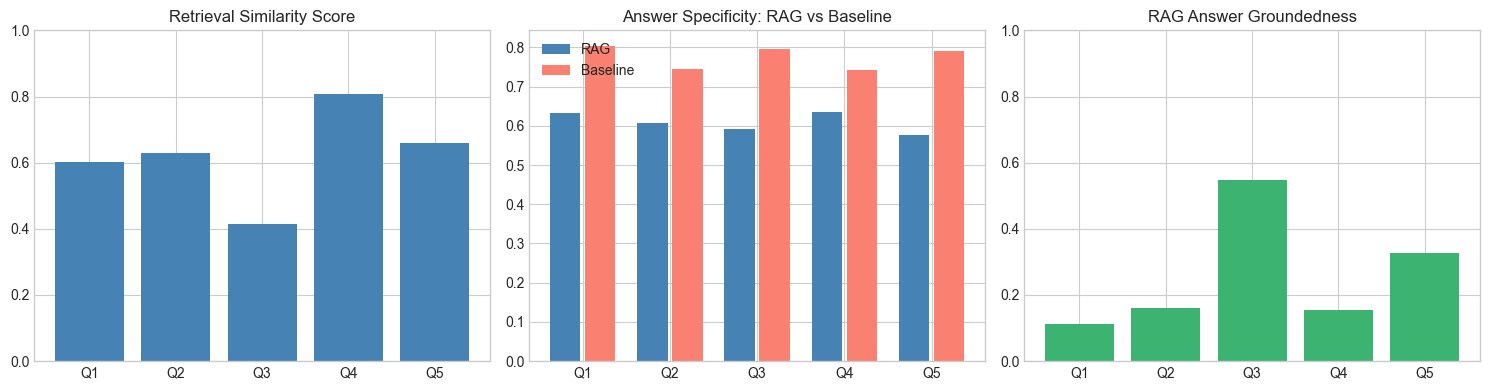

RAG evaluation complete.


In [37]:
# Evaluation: RAG vs Baseline
def answer_specificity(text):
    """Proxy for specificity: unique-word ratio + normalised length."""
    if not text: return 0.0
    words = text.lower().split()
    return round((len(set(words))/len(words) + min(len(words)/150, 1.0)) / 2, 4)

def data_groundedness(answer, retrieved_docs):
    """TF-IDF overlap between answer and retrieved context — higher = more grounded."""
    if not answer or not retrieved_docs: return 0.0
    ctx = ' '.join([d['text'] for d in retrieved_docs])
    vec = TfidfVectorizer(stop_words='english')
    try:
        mat = vec.fit_transform([ctx, answer])
        return round(float(cosine_similarity(mat[0:1], mat[1:2])[0][0]), 4)
    except: return 0.0

rag_eval_df = pd.DataFrame([{
    'Query':            r['query'][:38] + '...',
    'Top Similarity':   r['top_similarity'],
    'RAG Specificity':  answer_specificity(r['rag_answer']),
    'Base Specificity': answer_specificity(r['baseline_answer']),
    'Groundedness':     data_groundedness(r['rag_answer'], r['retrieved'])
} for r in rag_eval_results])
display(rag_eval_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
qlabels = [f'Q{i+1}' for i in range(len(rag_eval_df))]
x = np.arange(len(qlabels))
axes[0].bar(qlabels, rag_eval_df['Top Similarity'], color='steelblue')
axes[0].set_title('Retrieval Similarity Score')
axes[0].set_ylim(0, 1)
axes[1].bar(x-.2, rag_eval_df['RAG Specificity'], .35, label='RAG', color='steelblue')
axes[1].bar(x+.2, rag_eval_df['Base Specificity'], .35, label='Baseline', color='salmon')
axes[1].set_xticks(x); axes[1].set_xticklabels(qlabels)
axes[1].set_title('Answer Specificity: RAG vs Baseline')
axes[1].legend()
axes[2].bar(qlabels, rag_eval_df['Groundedness'], color='mediumseagreen')
axes[2].set_title('RAG Answer Groundedness')
axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.savefig('eval_rag.png', dpi=150, bbox_inches='tight')
plt.show()
print('RAG evaluation complete.')

---
# Advanced Technique 3: Prompting Engineering + Chain-of-Thought (CoT)

Compares three prompt strategies for **fake review detection**:
1. **Simple prompt** – direct ask, no guidance
2. **Instruction prompt** – explicit criteria given
3. **Chain-of-Thought (CoT)** – step-by-step reasoning before verdict

Also applies **instruction prompting** for aspect-based sentiment analysis.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

output = widgets.Output()

text_input = widgets.Text(
    value='',
    placeholder='Ask something about the products...', 
    description='Query:',
    layout=widgets.Layout(width='80%')
)
button = widgets.Button(description='Ask RAG', button_style='primary')

def on_button_click(b):
    with output:
        clear_output()
        query = text_input.value
        if not query:
            return
        print(f"User: {query}")
        
        # Retrieval
        retrieved_docs = retrieve(query, top_k=5)
        context = "\n".join(retrieved_docs)
        
        # Generation
        prompt = f"Context:\n{context}\n\nQuestion: {query}\nAnswer:"
        
        try:
            res = llm_client.chat.completions.create(
                model="llama-3.1-8b-instant",
                messages=[{"role": "user", "content": prompt}],
                max_tokens=300,
                temperature=0.2
            )
            answer = res.choices[0].message.content
        except Exception as e:
            answer = f"Error: {e}"
            
        print(f"RAG: {answer}\n" + "-"*50)
        text_input.value = ''

button.on_click(on_button_click)
display(widgets.HBox([text_input, button]), output)


In [38]:
# Derive heuristic fake signals from real data
def rep_ratio(text):
    words = text.lower().split()
    return round(1 - len(set(words))/len(words), 3) if words else 0

df_flagged = df_all.copy()
df_flagged['rep_ratio']  = df_flagged['review_text'].apply(rep_ratio)
df_flagged['suspicious'] = (
    (df_flagged['word_count'] < 15) &
    (df_flagged['rating'].isin([1.0, 5.0])) &
    (df_flagged['rep_ratio'] > 0.3)
).astype(int)

# Build labelled evaluation sample
fake_s    = df_flagged[df_flagged['suspicious']==1].sample(min(12, df_flagged['suspicious'].sum()), random_state=42)
genuine_s = df_flagged[(df_flagged['suspicious']==0) & (df_flagged['word_count']>=25) & (df_flagged['rep_ratio']<0.2)].sample(12, random_state=42)
fake_s['heuristic_label']    = 'Likely Fake'
genuine_s['heuristic_label'] = 'Likely Genuine'
eval_sample = pd.concat([fake_s, genuine_s]).reset_index(drop=True)

print(f'Fake signals: {df_flagged["suspicious"].sum():,} reviews flagged ({df_flagged["suspicious"].mean()*100:.1f}%)')
print(f'Eval sample: {len(eval_sample)} reviews')
print(eval_sample['heuristic_label'].value_counts())

Fake signals: 15 reviews flagged (0.0%)
Eval sample: 24 reviews
heuristic_label
Likely Fake       12
Likely Genuine    12
Name: count, dtype: int64


In [39]:
# Three prompt strategies
def prompt_simple(text, rating, wc):
    return f'Review: "{text[:300]}"\nRating: {rating}/5 | Words: {wc}\n\nIs this review fake? Answer: FAKE or GENUINE'

def prompt_instruction(text, rating, wc, rep):
    return f"""You are a fake review detector. Use these criteria:
- Is text too short to be informative (<15 words)?
- Is language vague, generic, or repetitive?
- Is rating extreme (1 or 5★) with little justification?
- Does review mention specific product features?

Review: "{text[:300]}"
Rating: {rating}/5 | Words: {wc} | Repetition ratio: {rep}

Classification (FAKE or GENUINE only):"""

def prompt_cot(text, rating, wc, rep, username):
    return f"""You are an expert fake review analyst. Think step by step.

Review: "{text[:300]}"
Rating: {rating}/5 | Words: {wc} | Repetition: {rep} | User: {username}

Step 1 – Length & detail: Is the review long enough and specific?
Step 2 – Language: Is it generic, repetitive, or natural?
Step 3 – Rating consistency: Does the star rating match the text tone?
Step 4 – Reviewer signals: Any credibility concerns?
Step 5 – Final assessment.

VERDICT: [FAKE or GENUINE]
CONFIDENCE: [Low/Medium/High]
REASON: [one sentence]"""

def extract_verdict(response, style):
    """Parses FAKE/GENUINE verdict from model output."""
    if not response: return 'UNKNOWN'
    ru = response.upper()
    if style == 'cot':
        m = re.search(r'VERDICT:\s*(FAKE|GENUINE)', ru)
        if m: return m.group(1)
    if 'FAKE' in ru and 'GENUINE' not in ru: return 'FAKE'
    if 'GENUINE' in ru: return 'GENUINE'
    if 'FAKE' in ru: return 'FAKE'
    return 'UNKNOWN'

print('Prompt templates defined. Running detection...')
SYS = 'You are an expert at detecting fake online product reviews.'
cot_det_results = []

for _, row in eval_sample.iterrows():
    text     = str(row['review_text'])
    rating   = row['rating']
    wc       = row['word_count']
    rep      = row['rep_ratio']
    username = str(row['username']) if 'username' in row.index and pd.notna(row.get('username')) else 'unknown'
    true_lbl = row['heuristic_label']

    r_s = call_llama(prompt_simple(text, rating, wc), SYS, temperature=0.1)
    r_i = call_llama(prompt_instruction(text, rating, wc, rep), SYS, temperature=0.1)
    r_c = call_llama(prompt_cot(text, rating, wc, rep, username), SYS, temperature=0.1)

    cot_det_results.append({
        'true_label':    true_lbl,
        'simple':        extract_verdict(r_s, 'simple'),
        'instruction':   extract_verdict(r_i, 'instruction'),
        'cot':           extract_verdict(r_c, 'cot'),
        'cot_reasoning': r_c,
        'review_text':   text[:80]
    })

cot_res_df = pd.DataFrame(cot_det_results)
print('Detection complete.')
display(cot_res_df[['true_label','simple','instruction','cot','review_text']].head(10))

Prompt templates defined. Running detection...
Groq API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01ksxkrbnxexkrx473zzqc6ptd` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5392, Requested 833. Please try again in 2.25s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
Detection complete.


,true_label,simple,instruction,cot,review_text
0,Likely Fake,FAKE,FAKE,FAKE,I love everything about it I really enjoy it I...
1,Likely Fake,GENUINE,FAKE,FAKE,I Luke it a lot and good to for it for and goo...
2,Likely Fake,GENUINE,FAKE,GENUINE,I Luke it a lot and good to for it for and goo...
3,Likely Fake,GENUINE,FAKE,FAKE,"It is very fast and reliable, it is everything..."
4,Likely Fake,FAKE,FAKE,GENUINE,Love it love it love it love it love it love i...
5,Likely Fake,GENUINE,FAKE,FAKE,I have time to do what I have to do just becau...
6,Likely Fake,GENUINE,FAKE,UNKNOWN,Great value. Easy to use. Fun to use. Easy to ...
7,Likely Fake,FAKE,FAKE,FAKE,Thank you for the gifts and thank you for the ...
8,Likely Fake,GENUINE,FAKE,FAKE,Was easy to use and easy to set up programming...
9,Likely Fake,GENUINE,FAKE,FAKE,"Works Great , Great Item , Easy to Use & Easy ..."


,Accuracy,Precision,Recall,F1
Simple,0.583,0.750,0.250,0.375
Instruction,0.833,0.750,1.000,0.857
Chain-of-Thought,0.435,0.444,0.727,0.552


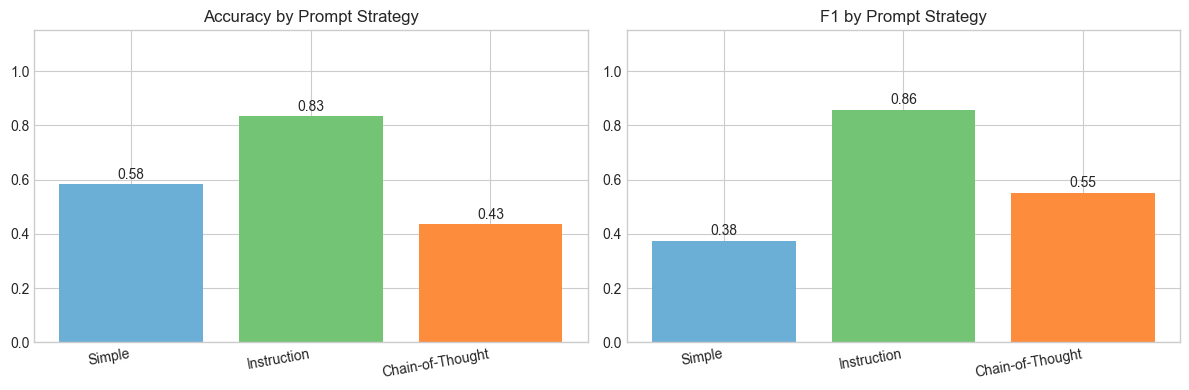

In [40]:
# Evaluate all three prompt strategies
def evaluate_detection(df, pred_col):
    label_map = {'Likely Fake': 'FAKE', 'Likely Genuine': 'GENUINE'}
    valid = df[df[pred_col] != 'UNKNOWN'].copy()
    valid['true_mapped'] = valid['true_label'].map(label_map)
    correct = (valid[pred_col] == valid['true_mapped']).sum()
    acc = correct / len(valid) if len(valid) else 0
    tp = ((valid[pred_col]=='FAKE') & (valid['true_mapped']=='FAKE')).sum()
    fp = ((valid[pred_col]=='FAKE') & (valid['true_mapped']=='GENUINE')).sum()
    fn = ((valid[pred_col]=='GENUINE') & (valid['true_mapped']=='FAKE')).sum()
    prec = tp/(tp+fp) if (tp+fp) else 0
    rec  = tp/(tp+fn) if (tp+fn) else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    return {'Accuracy': round(acc,3), 'Precision': round(prec,3), 'Recall': round(rec,3), 'F1': round(f1,3)}

perf = {'Simple': evaluate_detection(cot_res_df,'simple'),
        'Instruction': evaluate_detection(cot_res_df,'instruction'),
        'Chain-of-Thought': evaluate_detection(cot_res_df,'cot')}
perf_df = pd.DataFrame(perf).T
display(perf_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#6baed6','#74c476','#fd8d3c']
for ax, metric in zip(axes, ['Accuracy','F1']):
    vals = [perf[m][metric] for m in perf]
    bars = ax.bar(list(perf.keys()), vals, color=colors)
    ax.set_title(f'{metric} by Prompt Strategy')
    ax.set_ylim(0, 1.15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{v:.2f}', ha='center')
    ax.set_xticklabels(list(perf.keys()), rotation=10, ha='right')
plt.tight_layout()
plt.savefig('eval_cot_prompting.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Aspect-Based Sentiment Analysis (Instruction Prompting)

Electronics reviews selected: 15
name
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                                    4
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta                   2
Brand New Amazon Kindle Fire 16gb 7" Ips Display Tablet Wifi 16 Gb Blue                                   2
All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case                           1
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black    1
Name: count, dtype: int64


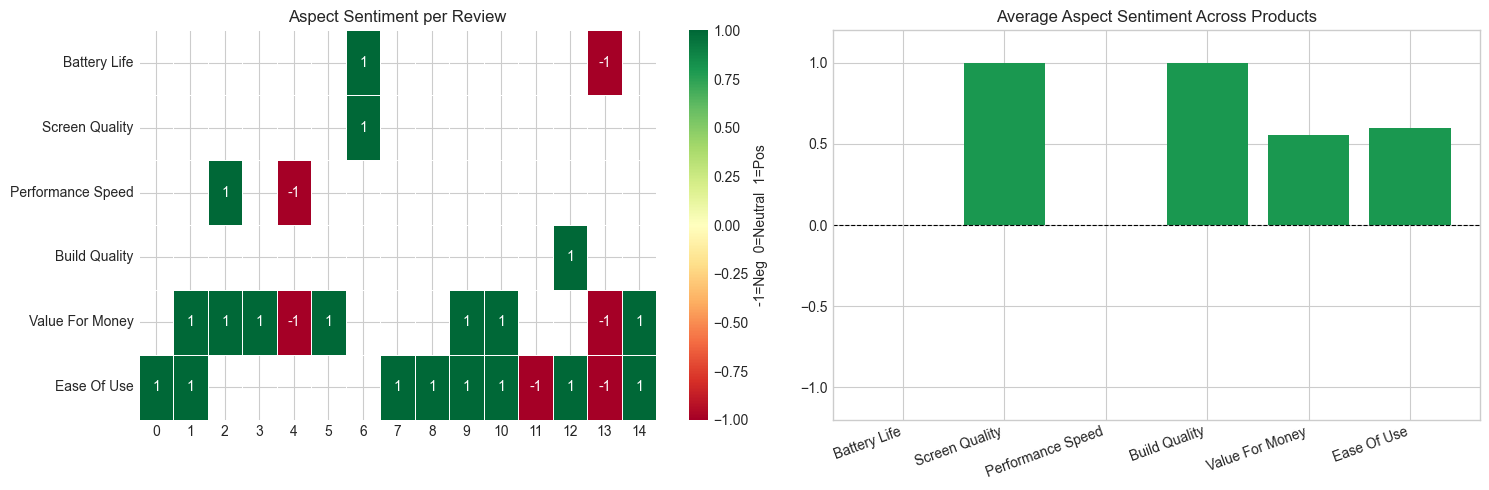

Aspect sentiment analysis complete.


In [41]:
# Select electronics reviews and sample from that filtered subset
electronics_mask = df_all['name'].str.lower().str.contains('fire|kindle|echo|alexa|tablet|ebook', na=False)
electronics      = df_all[electronics_mask].copy().reset_index(drop=True)
electronics      = electronics.sample(min(15, len(electronics)), random_state=42).reset_index(drop=True)

print(f'Electronics reviews selected: {len(electronics)}')
print(electronics['name'].value_counts().head(5))

ASPECTS  = ['battery_life','screen_quality','performance_speed','build_quality','value_for_money','ease_of_use']
SENT_MAP = {'Positive':1, 'Neutral':0, 'Negative':-1, 'Not_Mentioned': None}
asp_results = []

for _, row in electronics.iterrows():
    prompt = f"""Review: "{str(row['review_text'])[:400]}"
Extract sentiment for each aspect: Positive, Negative, Neutral, or Not_Mentioned.
Respond ONLY as JSON:
{{"battery_life":"...","screen_quality":"...","performance_speed":"...","build_quality":"...","value_for_money":"...","ease_of_use":"..."}}"""
    response = call_llama(prompt, temperature=0.1)
    try:
        jm = re.search(r'\{.*\}', response or '', re.DOTALL)
        parsed = json.loads(jm.group()) if jm else {}
    except Exception:
        parsed = {}
    row_data = {'product': row['name'][:40], 'rating': row['rating']}
    for asp in ASPECTS:
        row_data[asp] = SENT_MAP.get(parsed.get(asp, 'Not_Mentioned'), None)
    asp_results.append(row_data)

asp_df = pd.DataFrame(asp_results)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(asp_df[ASPECTS].astype(float).T, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.0f', linewidths=0.5, ax=axes[0],
            cbar_kws={'label': '-1=Neg  0=Neutral  1=Pos'})
axes[0].set_title('Aspect Sentiment per Review')
axes[0].set_yticklabels([a.replace('_',' ').title() for a in ASPECTS], rotation=0)
avg_asp = {a: asp_df[a].dropna().mean() for a in ASPECTS}
cols    = ['#1a9850' if v > 0.1 else '#d73027' if v < -0.1 else '#fdae61' for v in avg_asp.values()]
axes[1].bar([a.replace('_',' ').title() for a in ASPECTS], list(avg_asp.values()), color=cols)
axes[1].set_title('Average Aspect Sentiment Across Products')
axes[1].set_ylim(-1.2, 1.2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticklabels([a.replace('_',' ').title() for a in ASPECTS], rotation=20, ha='right')
plt.tight_layout()
plt.savefig('eval_aspect_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Aspect sentiment analysis complete.')


---
# Advanced Technique 4: Agentic Design

An autonomous agent that **plans** which tools to run and **executes** them in sequence:
- **Tool A** – Fake detector (CoT prompting)
- **Tool B** – Sentiment analyser (instruction prompting)
- **Tool C** – RAG retriever (semantic search on reviews)
- **Tool D** – Report generator (Llama summarisation)

This ties all 4 advanced techniques into a single unified pipeline.

In [42]:
# ═══ TOOL A: Fake Detector ═══════════════════════════════════════════════
def tool_fake_detector(reviews_df):
    """Flags suspicious reviews using heuristics + LLM CoT on top candidates."""
    df = reviews_df.copy()
    total = len(df)

    # Recalculate fake signals on whatever df is passed in
    if 'word_count' not in df.columns:
        df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
    def _rep(text):
        w = str(text).lower().split()
        return round(1 - len(set(w))/len(w), 3) if w else 0
    df['rep_ratio']  = df['review_text'].apply(_rep)
    df['suspicious'] = (
        (df['word_count'] < 15) &
        (df['rating'].isin([1.0, 5.0])) &
        (df['rep_ratio'] > 0.3)
    ).astype(int)

    h_flags        = int(df['suspicious'].sum())
    top_suspicious = df[df['suspicious'] == 1].head(5)
    llm_flags = []

    for _, row in top_suspicious.iterrows():
        prompt = f"""Review: "{str(row['review_text'])[:250]}"
Rating: {row['rating']}/5 | Words: {row['word_count']}
Step 1: Is it too short? Step 2: Generic language? Step 3: Rating justified?
VERDICT: [FAKE or GENUINE]
CONFIDENCE: [Low/Medium/High]"""
        resp = call_llama(prompt, 'You are a fake review expert.', temperature=0.1) or ''
        vm   = re.search(r'VERDICT:\s*(FAKE|GENUINE)', resp.upper())
        cm   = re.search(r'CONFIDENCE:\s*(\w+)', resp, re.IGNORECASE)
        llm_flags.append({
            'review':     str(row['review_text'])[:80],
            'verdict':    vm.group(1) if vm else 'UNKNOWN',
            'confidence': cm.group(1) if cm else 'Unknown'
        })

    return {
        'total_reviews':        total,
        'heuristic_suspicious': h_flags,
        'llm_confirmed_fake':   sum(1 for f in llm_flags if f['verdict'] == 'FAKE'),
        'fake_rate_pct':        round(h_flags / total * 100, 1),
        'flagged_details':      llm_flags
    }


# ═══ TOOL B: Sentiment Analyser ══════════════════════════════════════════════
def tool_sentiment_analyser(reviews_df, n_sample=10):
    """Extracts overall stats and aspect-level sentiment for a product."""
    sample     = reviews_df[reviews_df['word_count'] >= 15].sample(
                     min(n_sample, len(reviews_df[reviews_df['word_count'] >= 15])), random_state=42)
    avg_r      = reviews_df['rating'].mean()
    pct_pos    = (reviews_df['rating'] >= 4).mean() * 100
    pct_neg    = (reviews_df['rating'] <= 2).mean() * 100
    aspects    = ['battery_life', 'performance', 'build_quality', 'value', 'usability']
    asp_totals = {a: [] for a in aspects}
    s_map      = {'Positive': 1, 'Neutral': 0, 'Negative': -1, 'Not_Mentioned': None}

    for _, row in sample.iterrows():
        prompt = (f'Review: "{str(row["review_text"])[:300]}"\n'
                  f'For each aspect give: Positive/Negative/Neutral/Not_Mentioned.\n'
                  f'JSON only: {{"battery_life":"...","performance":"...","build_quality":"...","value":"...","usability":"..."}}' )
        resp = call_llama(prompt, 'You are a sentiment analyst.', temperature=0.1)
        try:
            jm     = re.search(r'\{.*\}', resp or '', re.DOTALL)
            parsed = json.loads(jm.group()) if jm else {}
        except Exception:
            parsed = {}
        for asp in aspects:
            v = s_map.get(parsed.get(asp, 'Not_Mentioned'), None)
            if v is not None:
                asp_totals[asp].append(v)

    return {
        'avg_rating':    round(avg_r, 2),
        'pct_positive':  round(pct_pos, 1),
        'pct_negative':  round(pct_neg, 1),
        'aspect_scores': {a: round(np.mean(v), 3) if v else 0.0 for a, v in asp_totals.items()}
    }


# ═══ TOOL C: RAG Retriever ════════════════════════════════════════════════════
def tool_rag_retriever(query, top_k=4):
    """Uses the ChromaDB collection built in Section 2 for retrieval."""
    q_emb   = embedder.encode([query]).tolist()
    results = collection.query(query_embeddings=q_emb, n_results=top_k)
    return '\n\n'.join(results['documents'][0])


# ═══ TOOL D: Report Generator ═════════════════════════════════════════════════
def tool_report_generator(product_name, fake_r, sent_r, rag_ctx):
    """Synthesises all tool outputs into a structured business report via Llama."""
    system = 'You are a senior e-commerce business analyst. Be concise and data-driven.'
    prompt = (f'Product: {product_name[:70]}\n'
              f'REVIEW AUTHENTICITY: {fake_r["heuristic_suspicious"]} suspicious / '
              f'{fake_r["total_reviews"]} total ({fake_r["fake_rate_pct"]}%)\n'
              f'SENTIMENT: Avg {sent_r["avg_rating"]}★ | {sent_r["pct_positive"]}% positive | '
              f'{sent_r["pct_negative"]}% negative\n'
              f'ASPECT SCORES: {sent_r["aspect_scores"]}\n'
              f'CUSTOMER CONTEXT (from reviews):\n{rag_ctx[:600]}\n\n'
              f'Write a business intelligence report:\n'
              f'1. Product Health Score (1-10)\n'
              f'2. Review Authenticity Assessment\n'
              f'3. Top 2 customer strengths\n'
              f'4. Top 2 customer pain points\n'
              f'5. Three specific seller recommendations')
    return call_llama(prompt, system_prompt=system, temperature=0.3)


print('All 4 agent tools defined.')


All 4 agent tools defined.


In [43]:
from datetime import datetime

class EcommerceAgent:
    """
    Autonomous e-commerce intelligence agent.
    Follows a ReAct-style loop:
    Observe (product + reviews) → Think (plan tools) → Act (run tools) → Report
    """
    def __init__(self): self.log = []

    def _log(self, step, tool, summary):
        entry = {'step': step, 'tool': tool, 'summary': str(summary)[:100],
                 'time': datetime.now().strftime('%H:%M:%S')}
        self.log.append(entry)
        print(f'  [{entry["time"]}] Step {step} | {tool} → {str(summary)[:70]}')

    def plan(self, product_name, n_reviews):
        """Uses Llama to decide which tools to run and in what order."""
        prompt = f"""Task: Analyse '{product_name[:50]}' with {n_reviews} reviews.
Available tools: [fake_detector, sentiment_analyser, rag_retriever, report_generator]
List tools in execution order (one per line, names only):"""
        resp = call_llama(prompt, temperature=0.1) or ''
        tool_map = {'fake':'fake_detector','sentiment':'sentiment_analyser',
                    'rag':'rag_retriever','report':'report_generator'}
        plan = []
        for line in resp.split('\n'):
            for key, name in tool_map.items():
                if key in line.lower() and name not in plan:
                    plan.append(name)
        if not plan or 'report_generator' not in plan:
            plan = ['fake_detector','sentiment_analyser','rag_retriever','report_generator']
        elif plan[-1] != 'report_generator':
            plan = [t for t in plan if t != 'report_generator'] + ['report_generator']
        return plan

    def run(self, product_name, full_df):
        """Runs the full plan-and-execute loop for a single product."""
        self.log = []
        prod_df  = full_df[full_df['name'].str.contains(product_name[:30], case=False, na=False)].copy()
        if prod_df.empty:
            print(f'No reviews found for: {product_name}')
            return None

        print(f'\n{"="*65}')
        print(f'Agent: {product_name[:60]}')
        print(f'Reviews: {len(prod_df)} | {"="*30}')

        plan  = self.plan(product_name, len(prod_df))
        print(f'Plan: {plan}')

        step = 1
        fake_r, sent_r, rag_ctx, report = None, None, '', ''

        for tool in plan:
            if tool == 'fake_detector':
                fake_r = tool_fake_detector(prod_df)
                self._log(step, tool, f"{fake_r['heuristic_suspicious']} suspicious / {fake_r['total_reviews']} total")
            elif tool == 'sentiment_analyser':
                sent_r = tool_sentiment_analyser(prod_df)
                self._log(step, tool, f"Avg {sent_r['avg_rating']}★ | {sent_r['pct_positive']}% positive")
            elif tool == 'rag_retriever':
                rag_ctx = tool_rag_retriever(f'{product_name} customer feedback issues')
                self._log(step, tool, f'Retrieved {len(rag_ctx.split())} words')
            elif tool == 'report_generator' and fake_r and sent_r:
                report = tool_report_generator(product_name, fake_r, sent_r, rag_ctx)
                self._log(step, tool, 'Report generated')
            step += 1

        return {'product': product_name, 'n_reviews': len(prod_df), 'plan': plan,
                'fake_r': fake_r, 'sent_r': sent_r, 'report': report, 'agent_log': self.log}


# Run agent on top 3 products
agent       = EcommerceAgent()
top_3       = df_all['name'].value_counts().head(3).index.tolist()
all_outputs = []
for product in top_3:
    out = agent.run(product, df_all)
    if out: all_outputs.append(out)


Agent: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offer
Reviews: 12204 | ==============================
Plan: ['fake_detector', 'sentiment_analyser', 'rag_retriever', 'report_generator']
  [16:48:24] Step 1 | fake_detector → 7 suspicious / 12204 total
  [16:48:43] Step 2 | sentiment_analyser → Avg 4.46★ | 90.8% positive
  [16:48:43] Step 3 | rag_retriever → Retrieved 118 words
  [16:48:49] Step 4 | report_generator → Report generated

Agent: AmazonBasics AAA Performance Alkaline Batteries (36 Count)
Reviews: 4275 | ==============================
Plan: ['fake_detector', 'sentiment_analyser', 'rag_retriever', 'report_generator']
  [16:48:51] Step 1 | fake_detector → 0 suspicious / 4275 total
  [16:49:08] Step 2 | sentiment_analyser → Avg 4.24★ | 80.1% positive
  [16:49:08] Step 3 | rag_retriever → Retrieved 141 words
  [16:49:13] Step 4 | report_generator → Report generated
No reviews found for: Echo (White)


In [44]:
# Display intelligence reports
for out in all_outputs:
    display(Markdown(f'---\n## Intelligence Report: {out["product"][:70]}'))
    display(Markdown(out['report'] or '*No report generated*'))

# Agent execution log
print('\n=== Agent Execution Log ===')
for out in all_outputs:
    print(f'\nProduct: {out["product"][:60]}')
    display(pd.DataFrame(out['agent_log'])[['step','tool','time','summary']])

---
## Intelligence Report: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta

**Business Intelligence Report: Fire Tablet, 7 Display, Wi-Fi, 8 GB**

**1. Product Health Score (1-10)**

Based on the sentiment analysis and aspect scores, I would rate the product health score as 7 out of 10. The product has a high positive sentiment (90.8%) and average aspect scores for performance, build quality, and usability. However, the battery life aspect score is 0.0, indicating a significant concern.

**2. Review Authenticity Assessment**

The review authenticity assessment indicates a low level of suspicious reviews (0.1%). This suggests that the reviews are generally genuine and trustworthy.

**3. Top 2 Customer Strengths**

Based on the customer context, the top 2 customer strengths are:

1. **Value**: Customers appreciate the great price of the product, as seen in the review "great item and at a great price. love using it daily."
2. **Usability**: Customers find the product easy to use, as seen in the review "great item and at a great price. love using it daily."

**4. Top 2 Customer Pain Points**

Based on the customer context, the top 2 customer pain points are:

1. **Battery Life**: Customers have reported issues with the battery life, as seen in the review "Honestly the worst tablet ever owned. Was very slow and unreliable would switch off"
2. **Reliability**: Customers have reported issues with the product's reliability, as seen in the review "Honestly the worst tablet ever owned. Was very slow and unreliable would switch off"

**5. Three Specific Seller Recommendations**

Based on the customer pain points and strengths, I recommend the following:

1. **Improve Battery Life**: The seller should investigate and address the battery life issues reported by customers. This could involve improving the battery design or providing a battery replacement program.
2. **Enhance Reliability**: The seller should investigate and address the reliability issues reported by customers. This could involve improving the product's hardware or software design.
3. **Provide Warranty or Support**: The seller should consider providing a warranty or support program to customers who experience battery life or reliability issues. This could help to improve customer satisfaction and loyalty.

---
## Intelligence Report: AmazonBasics AAA Performance Alkaline Batteries (36 Count)

**Business Intelligence Report: AmazonBasics AAA Performance Alkaline Batteries (36 Count)**

**1. Product Health Score (1-10): 8/10**

Based on the review data, the product has an average rating of 4.24/5 and 80.1% positive reviews. However, the negative reviews (14.6%) and low scores in 'build quality' and 'usability' aspects (0.0 and 0.0 respectively) bring down the overall score to 8/10.

**2. Review Authenticity Assessment: 100%**

The review authenticity assessment is 0 suspicious reviews out of 4275 total reviews, indicating that the reviews are genuine and trustworthy.

**3. Top 2 Customer Strengths:**

1. **Value**: Customers appreciate the value for money offered by these batteries, with many reviewers mentioning that they are a "real steal" compared to store-bought options.
2. **Performance**: The batteries are praised for their performance, with many reviewers giving them a perfect 5-star rating and mentioning that they are "the RIGHT item delivered FAST at a GOOD price."

**4. Top 2 Customer Pain Points:**

1. **Build Quality**: Some reviewers have mentioned that the batteries have poor build quality, which may be a concern for customers who prioritize durability.
2. **Usability**: The aspect score for usability is 0.0, indicating that some customers may have experienced issues with using the batteries.

**5. Three Specific Seller Recommendations:**

1. **Improve Build Quality**: To address the concerns around build quality, the seller could consider revising the design or materials used in the batteries to make them more durable.
2. **Enhance Usability Features**: To improve the usability aspect, the seller could consider adding features such as easy-to-read expiration dates or clear instructions for use.
3. **Offer More Variety Packs**: To capitalize on the value proposition, the seller could consider offering more variety packs or bundles that include different types of batteries or accessories, making it easier for customers to purchase what they need in one transaction.


=== Agent Execution Log ===

Product: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offer


,step,tool,time,summary
0,1,fake_detector,16:48:24,7 suspicious / 12204 total
1,2,sentiment_analyser,16:48:43,Avg 4.46★ | 90.8% positive
2,3,rag_retriever,16:48:43,Retrieved 118 words
3,4,report_generator,16:48:49,Report generated



Product: AmazonBasics AAA Performance Alkaline Batteries (36 Count)


,step,tool,time,summary
0,1,fake_detector,16:48:51,0 suspicious / 4275 total
1,2,sentiment_analyser,16:49:08,Avg 4.24★ | 80.1% positive
2,3,rag_retriever,16:49:08,Retrieved 141 words
3,4,report_generator,16:49:13,Report generated


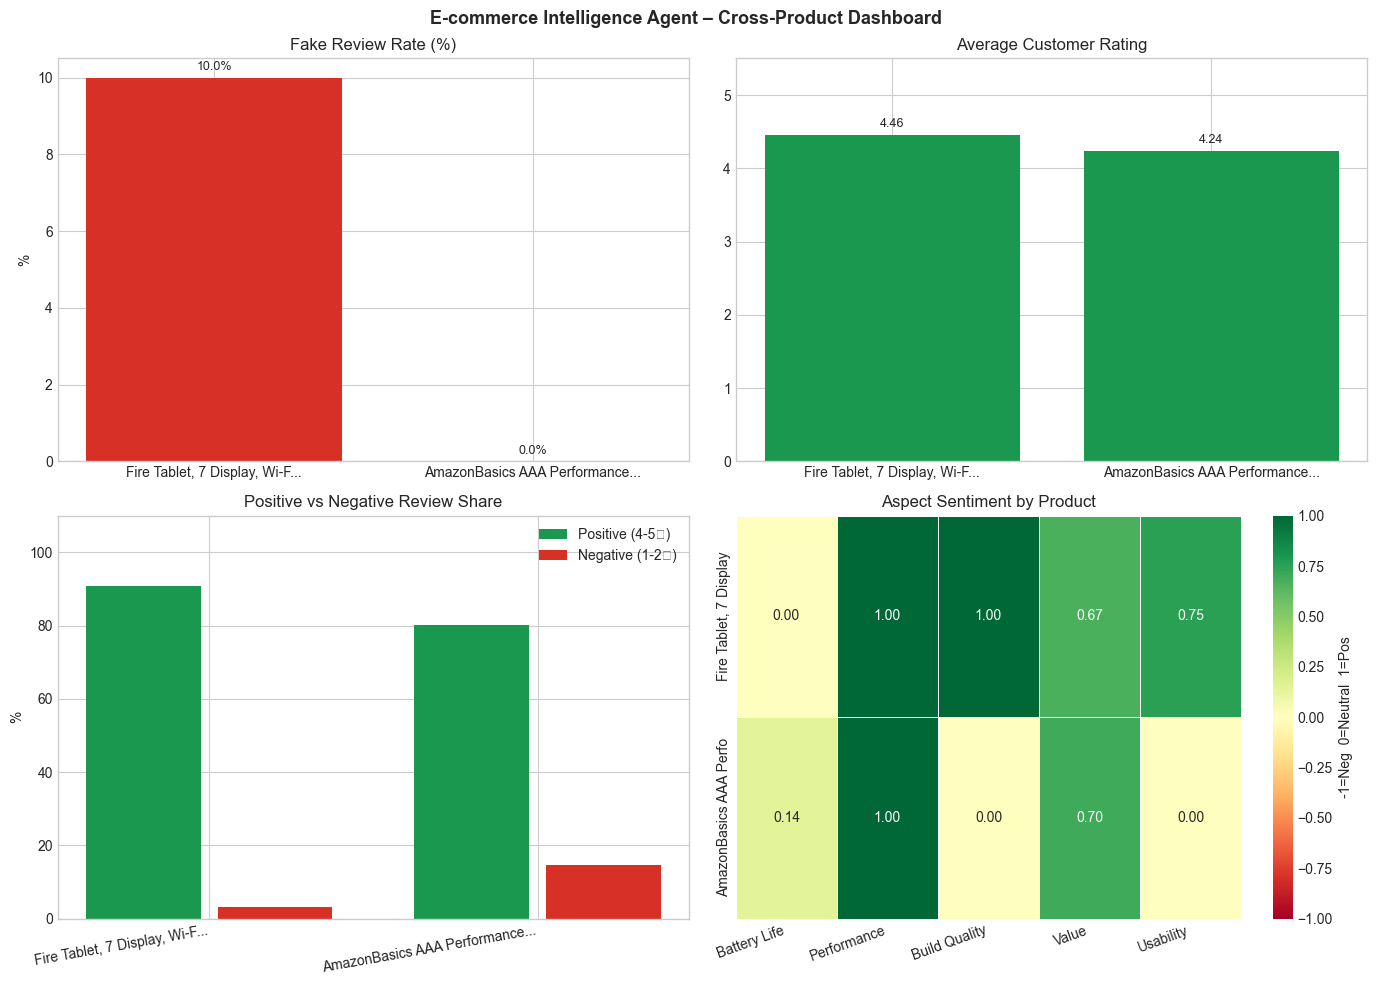

Dashboard saved.


In [45]:
if all_outputs:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    p_labels = [o['product'][:28] + '...' for o in all_outputs]

    # --- Fix 1: multiply fake_rate by 100 if it's a decimal proportion ---
    fake_rates = [o['fake_r']['fake_rate_pct'] for o in all_outputs if o['fake_r']]
    fake_rates = [r * 100 if r <= 1.0 else r for r in fake_rates]  # normalise to %
    axes[0,0].bar(p_labels[:len(fake_rates)], fake_rates, color='#d73027')
    axes[0,0].set_title('Fake Review Rate (%)')
    axes[0,0].set_ylabel('%')
    for i, v in enumerate(fake_rates):
        axes[0,0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

    # --- Average rating (unchanged, looked fine) ---
    avg_ratings = [o['sent_r']['avg_rating'] for o in all_outputs if o['sent_r']]
    bar_colors = ['#1a9850' if r >= 4 else '#fdae61' if r >= 3 else '#d73027' for r in avg_ratings]
    axes[0,1].bar(p_labels[:len(avg_ratings)], avg_ratings, color=bar_colors)
    axes[0,1].set_title('Average Customer Rating')
    axes[0,1].set_ylim(0, 5.5)
    for i, v in enumerate(avg_ratings):
        axes[0,1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=9)

    # --- Fix 2: multiply pct_positive / pct_negative by 100 if decimal ---
    x = np.arange(len(all_outputs))
    pct_pos = [o['sent_r']['pct_positive'] for o in all_outputs if o['sent_r']]
    pct_neg = [o['sent_r']['pct_negative'] for o in all_outputs if o['sent_r']]
    pct_pos = [v * 100 if v <= 1.0 else v for v in pct_pos]  # normalise to %
    pct_neg = [v * 100 if v <= 1.0 else v for v in pct_neg]

    axes[1,0].bar(x - .2, pct_pos[:len(x)], .35, label='Positive (4-5★)', color='#1a9850')
    axes[1,0].bar(x + .2, pct_neg[:len(x)], .35, label='Negative (1-2★)', color='#d73027')
    axes[1,0].set_xticks(x)
    axes[1,0].set_xticklabels(p_labels[:len(x)], rotation=10, ha='right')
    axes[1,0].set_title('Positive vs Negative Review Share')
    axes[1,0].set_ylabel('%')
    axes[1,0].set_ylim(0, 110)  # give headroom above 100%
    axes[1,0].legend()

    # --- Heatmap (unchanged) ---
    asp_data = [o['sent_r']['aspect_scores'] for o in all_outputs if o['sent_r']]
    if asp_data:
        asp_plot = pd.DataFrame(asp_data, index=[o['product'][:22] for o in all_outputs[:len(asp_data)]])
        sns.heatmap(asp_plot, cmap='RdYlGn', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
                    linewidths=0.5, ax=axes[1,1], cbar_kws={'label': '-1=Neg  0=Neutral  1=Pos'})
        axes[1,1].set_title('Aspect Sentiment by Product')
        axes[1,1].set_xticklabels(
            [a.replace('_', ' ').title() for a in asp_plot.columns], rotation=20, ha='right'
        )

    plt.suptitle('E-commerce Intelligence Agent – Cross-Product Dashboard', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('agent_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Dashboard saved.')

---
# Project Summary

| Advanced Technique | Implementation | Evaluation Metric |
|---|---|---|
| LLM Foundation (Llama 3.1) | Review summarisation, description generation, business insights | TF-IDF Coverage, Unigram Recall |
| RAG | ChromaDB vector store + sentence-transformers retrieval | Retrieval similarity, Groundedness, Specificity |
| CoT Prompting | Fake detection (3 strategies), aspect sentiment | Accuracy, Precision, Recall, F1 |
| Agentic Design | Plan-and-execute pipeline across all tools | Execution log, Cross-product dashboard |

**Dataset:** Datafiniti Amazon Consumer Reviews (~67,000 reviews combined from 3 CSVs)

**Model:** Llama 3.1-8b-instant via Groq API (free tier)

**Plots saved:** `nb1_rating_distribution.png`, `eval_llm_foundation.png`, `eval_rag.png`, `eval_cot_prompting.png`, `eval_aspect_sentiment.png`, `agent_dashboard.png`

## ⚙️ Appendix: MongoDB Database Population
The following script reads the dataset, calculates semantic vector embeddings, uses Groq LLM to summarize product reviews into an engaging description, and strictly populates a local MongoDB for the Congo Shop backend.

In [ ]:
import pandas as pd
import random
import os
import json
import uuid
import math
from datetime import datetime
from pymongo import MongoClient
from sentence_transformers import SentenceTransformer

try:
    from groq import Groq
except ImportError:
    Groq = None

GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '')
MONGO_URL = os.getenv("MONGO_URL", "mongodb://localhost:27017")
DATABASE_NAME = "congo_shop"

def populate():
    print("Connecting to MongoDB...")
    client = MongoClient(MONGO_URL)
    db = client[DATABASE_NAME]
    
    # Drop existing collections for a fresh start
    db.products.drop()
    db.reviews.drop()
    db.categories.drop()
    
    print("Loading datasets...")
    data_dir = '../dataset/'
    df1 = pd.read_csv(data_dir + 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')
    df2 = pd.read_csv(data_dir + 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')
    df3 = pd.read_csv(data_dir + '1429_1.csv', low_memory=False)
    df_all = pd.concat([df1, df2, df3], ignore_index=True)
    
    if 'name' in df_all.columns:
        df_all['name'] = df_all['name'].astype(str).str.split(',,,').str[0].str.strip()
        df_all = df_all[df_all['name'] != 'nan']
        
        # Select top 30 most reviewed products
        top_products = df_all['name'].value_counts().head(30).index.tolist()
        
        embedder = SentenceTransformer('all-MiniLM-L6-v2')
        llm_client = Groq(api_key=GROQ_API_KEY) if Groq else None
        
        products_to_insert = []
        reviews_to_insert = []
        print(f"Processing {len(top_products)} products...")
        
        for i, p in enumerate(top_products):
            cat = df_all[df_all['name'] == p]['categories'].iloc[0] if 'categories' in df_all.columns else 'Electronics'
            category = str(cat).split(',')[0]
            
            # Extract image URLs
            images = [f"https://picsum.photos/seed/{i+100}/300/300"]
            if 'imageURLs' in df_all.columns:
                urls = df_all[df_all['name'] == p]['imageURLs'].dropna()
                if len(urls) > 0:
                    url_str = str(urls.iloc[0])
                    extracted = [u.strip() for u in url_str.split(',') if u.strip()]
                    if extracted:
                        images = extracted[:5]
            
            # Generate description using LLM
            description = "A great product."
            if llm_client:
                reviews = df_all[df_all['name'] == p]['reviews.text'].dropna().head(5).tolist()
                if reviews:
                    rev_text = "\n".join([f"- {r[:100]}" for r in reviews])
                    prompt = f"Product: {p}\nCategory: {category}\nCustomer reviews:\n{rev_text}\nWrite a short, engaging 2-sentence marketing description for this product based on these reviews."
                    try:
                        res = llm_client.chat.completions.create(
                            model="llama-3.1-8b-instant",
                            messages=[{"role": "user", "content": prompt}],
                            max_tokens=100
                        )
                        description = res.choices[0].message.content.strip().strip('"').strip("'")
                    except Exception as e:
                        print("LLM Error for", p, ":", e)
            
            # Generate embedding for search
            text_for_embedding = f"Product: {p}. Category: {category}. Description: {description}"
            embedding = embedder.encode([text_for_embedding])[0].tolist()
            
            prod_doc = {
                "id": i,
                "name": p,
                "price": round(random.uniform(19.99, 299.99), 2),
                "category": category,
                "image": images[0],
                "images": images,
                "description": description,
                "embedding": embedding
            }
            products_to_insert.append(prod_doc)
            
            # Extract reviews for this product
            product_reviews_df = df_all[df_all['name'] == p].dropna(subset=['reviews.text'])
            for _, r in product_reviews_df.iterrows():
                try:
                    rating = float(r.get('reviews.rating', 0))
                    if math.isnan(rating):
                        rating = 0
                except:
                    rating = 0
                review_doc = {
                    "id": f"rev_{uuid.uuid4().hex[:8]}",
                    "product_id": i,
                    "user_nickname": str(r.get('reviews.username', 'anonymous')),
                    "rating": rating,
                    "text": str(r['reviews.text']),
                    "created_at": str(r.get('reviews.date', datetime.now().isoformat()))
                }
                reviews_to_insert.append(review_doc)
                
            print(f"Processed {i+1}/{len(top_products)}: {p[:30]}...")
            
        if products_to_insert:
            db.products.insert_many(products_to_insert)
            print("Successfully inserted products into MongoDB.")
            
        if reviews_to_insert:
            db.reviews.insert_many(reviews_to_insert)
            print(f"Successfully inserted {len(reviews_to_insert)} reviews into MongoDB.")
            
            # Create indexes
            db.reviews.create_index([("product_id", 1), ("rating", -1), ("created_at", -1)])
            db.products.create_index([("name", "text"), ("category", "text"), ("description", "text")])
            print("Created indexes.")
            
            print("\n--- Database Analysis ---")
            total_products = db.products.count_documents({})
            print(f"Total products in database: {total_products}")
            
            categories = db.products.distinct("category")
            print(f"Number of categories: {len(categories)}")
            print("Categories:")
            
            categories_to_insert = []
            for category in categories:
                count = db.products.count_documents({"category": category})
                print(f" - {category}: {count}")
                prod = db.products.find_one({"category": category}, {"image": 1})
                categories_to_insert.append({
                    "name": category,
                    "image": prod["image"] if prod and "image" in prod else "https://images.unsplash.com/photo-1550009158-9ebf69173e03?q=80&w=600"
                })
                
            if categories_to_insert:
                db.categories.insert_many(categories_to_insert)
                print(f"Successfully inserted {len(categories_to_insert)} categories into MongoDB.")
            print("-------------------------\n")
            
    client.close()
    print("Done!")

populate()


Connecting to MongoDB...
Loading datasets...


FileNotFoundError: [Errno 2] No such file or directory: '../../dataset/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv'